# Baseline Model: Linear Regression

This notebook implements the project baseline model for **national electricity demand forecasting** using:
- lagged demand features (autoregressive signal)
- socio-economic features (`gdp`, `population`, `gdp_per_capita`)

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 2003-2019, Test = 2020-2023  
**Metrics:** RMSE and MAE

In [79]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [80]:
# Load dataset
DATA_PATH = 'df_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: df_clean.csv
Shape: 6994 rows x 18 columns
Countries: 181
Year range: 1985-2024


,country,year,population,iso_code,gdp,biofuel_electricity,coal_electricity,electricity_demand,electricity_generation,fossil_electricity,gas_electricity,greenhouse_gas_emissions,hydro_electricity,nuclear_electricity,oil_electricity,renewables_electricity,solar_electricity,wind_electricity
0,American Samoa,1985,39128.0,ASM,6.040371e+08,0.0,0.0,0.078,0.078,0.078,NaN,0.018,0.0,0.0,NaN,0.0,0.0,0.0
1,American Samoa,1986,40588.0,ASM,6.894330e+08,0.0,0.0,0.084,0.084,0.084,NaN,0.024,0.0,0.0,NaN,0.0,0.0,0.0
2,American Samoa,1987,42095.0,ASM,7.549983e+08,0.0,0.0,0.090,0.090,0.090,NaN,0.030,0.0,0.0,NaN,0.0,0.0,0.0
3,American Samoa,1988,43634.0,ASM,7.891841e+08,0.0,0.0,0.096,0.096,0.096,NaN,0.036,0.0,0.0,NaN,0.0,0.0,0.0
4,American Samoa,1989,45207.0,ASM,8.419489e+08,0.0,0.0,0.102,0.102,0.102,NaN,0.042,0.0,0.0,NaN,0.0,0.0,0.0


In [81]:
# Feature engineering
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

# Lagged year-over-year change (no leakage): (t-1) - (t-2)
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)

# Exogenous interaction
df['gdp_per_capita'] = df['gdp'] / df['population']

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
df_model[['country', 'year'] + FEATURE_COLS + [TARGET]].head()

Usable rows after lag features: 6451


,country,year,demand_lag1,demand_lag2,demand_lag3,demand_yoy_change,gdp,population,gdp_per_capita,electricity_demand
3,American Samoa,1988,0.090,0.084,0.078,0.006,7.891841e+08,43634.0,18086.449396,0.096
4,American Samoa,1989,0.096,0.090,0.084,0.006,8.419489e+08,45207.0,18624.303326,0.102
5,American Samoa,1990,0.102,0.096,0.090,0.006,8.735035e+08,46659.0,18721.008140,0.108
6,American Samoa,1991,0.108,0.102,0.096,0.006,9.136560e+08,47903.0,19073.043107,0.114
7,American Samoa,1992,0.114,0.108,0.102,0.006,9.605524e+08,49054.0,19581.530228,0.120


In [82]:
# Temporal train/test split
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows: {len(test)}')
print(f'Features: {FEATURE_COLS}')

Train rows: 5623
Test rows: 828
Features: ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [83]:
# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [84]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 12.211 TWh | Train MAE: 2.437 TWh
Test RMSE : 23.986 TWh | Test MAE : 5.263 TWh


In [85]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
29,China,5,256.924,222.675
173,United States,5,132.332,130.543
72,India,5,69.984,55.558
133,Russia,5,35.483,29.834
78,Japan,5,32.488,27.542
...,...,...,...,...
151,Somalia,4,0.137,0.133
13,Benin,4,0.101,0.096
154,South Sudan,5,0.098,0.091
134,Rwanda,4,0.058,0.048


In [86]:
# Coefficients (interpretability)
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: -0.4513


,feature,coefficient
0,demand_lag1,9.062015e-01
3,demand_yoy_change,5.497474e-01
1,demand_lag2,3.564534e-01
2,demand_lag3,-2.512056e-01
6,gdp_per_capita,-2.449995e-06
5,population,3.880738e-08
4,gdp,-2.400136e-12


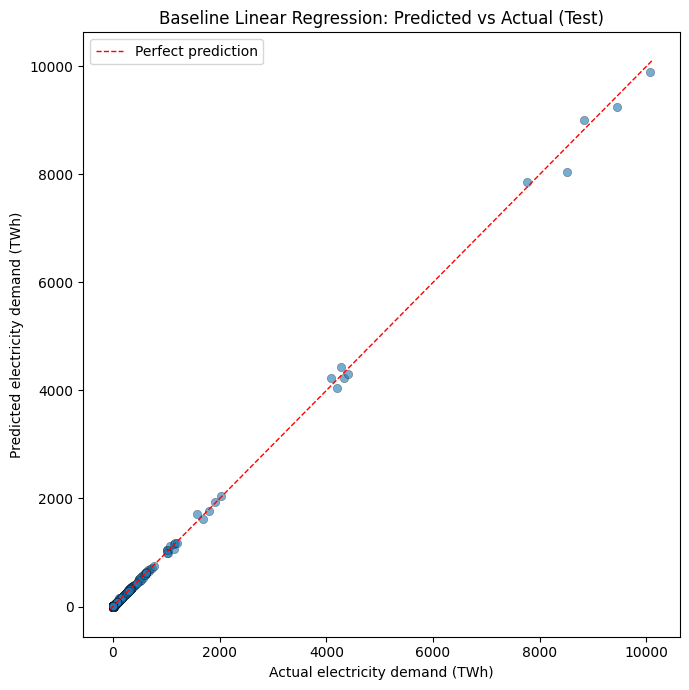

In [87]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

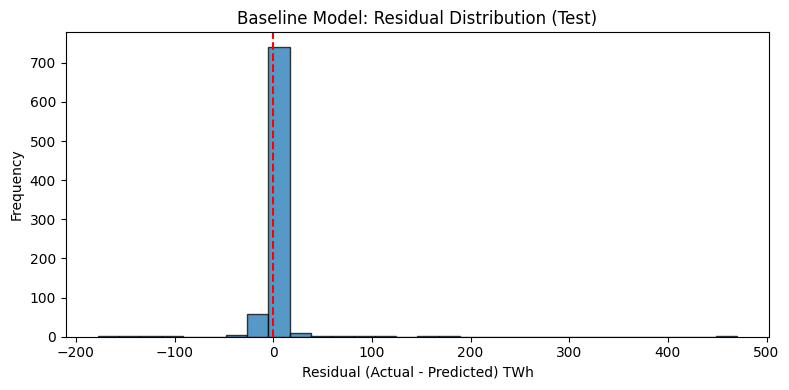

In [88]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

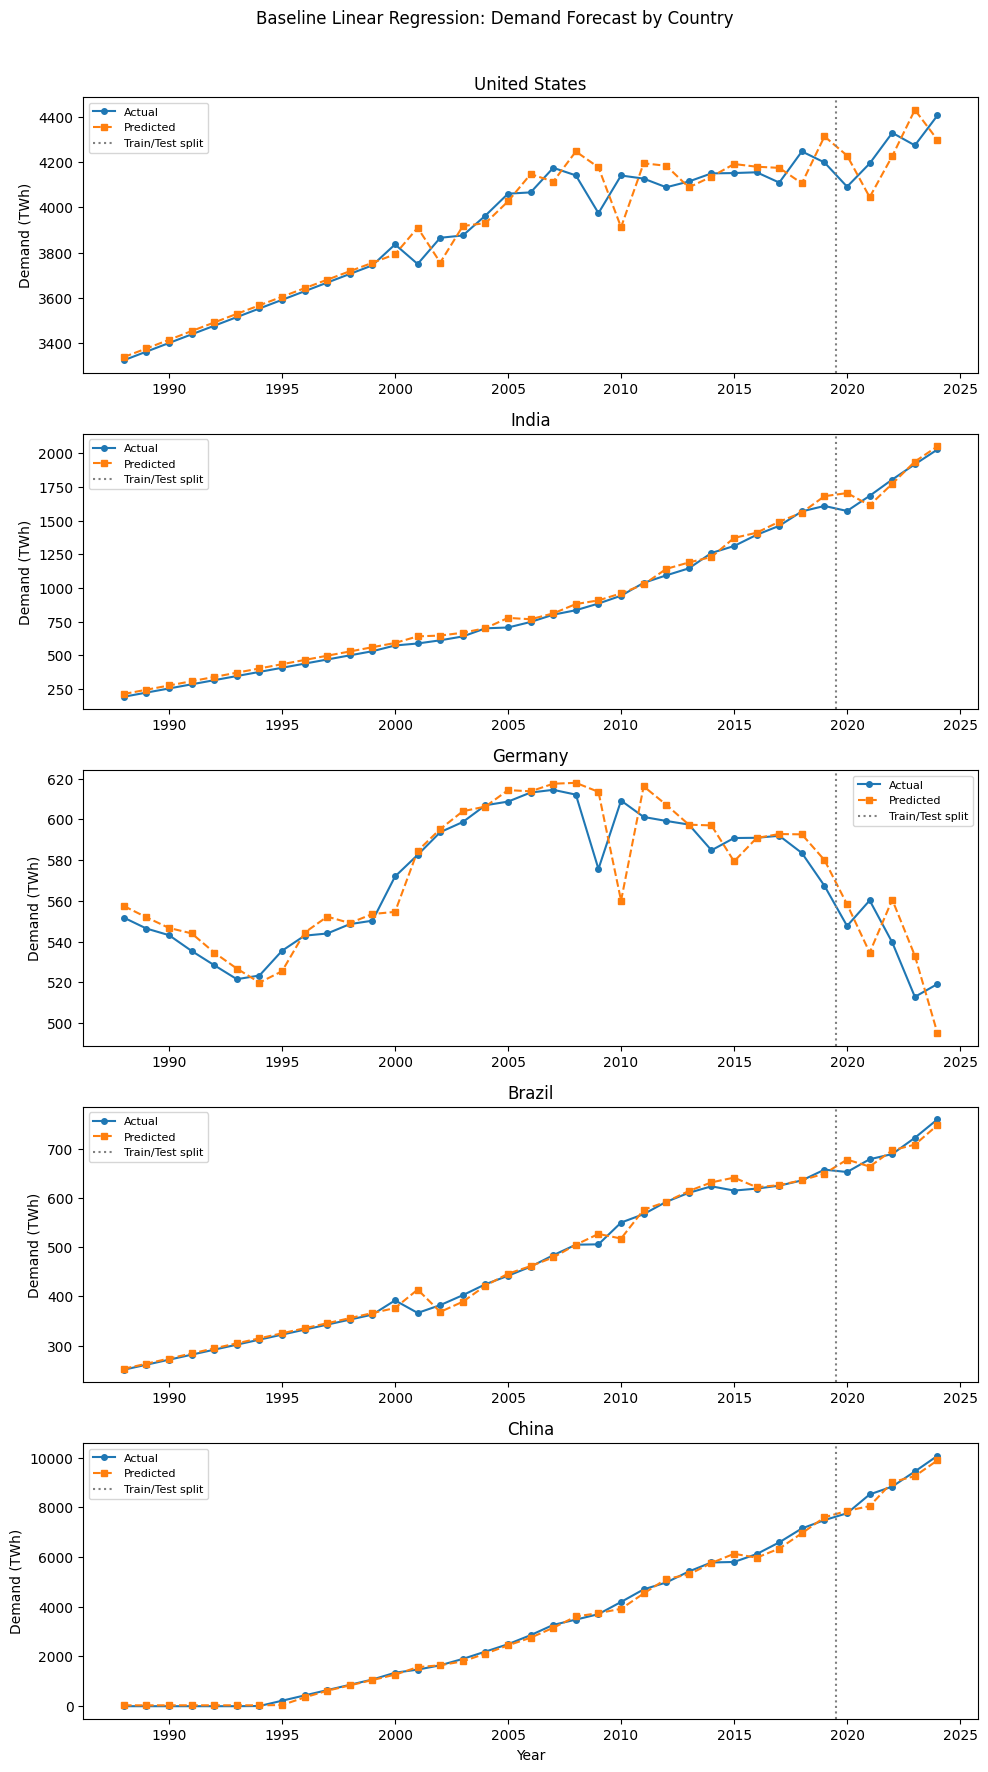

In [89]:
# Plot 3: Country-level overlays
preferred_countries = ['United States', 'India', 'Germany', 'Brazil', 'China']
available_countries = df_model['country'].unique()
sample_countries = [c for c in preferred_countries if c in available_countries]

# Fall back to top-4 countries by test RMSE if none of the defaults are present
if not sample_countries:
    sample_countries = country_metrics['country'].head(4).tolist()

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    cdf['predicted'] = model.predict(cdf[FEATURE_COLS])

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Baseline Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()


In [90]:
# Table of actual vs predicted for for all countries in test set
results_df = test[['country', 'year', TARGET]].copy()
results_df['predicted'] = y_pred_test
results_df.head(30)

,country,year,electricity_demand,predicted
35,American Samoa,2020,0.170000,-0.384165
36,American Samoa,2021,0.170000,-0.373958
37,American Samoa,2022,0.180000,-0.378072
38,American Samoa,2023,0.170000,-0.365614
74,Antigua and Barbuda,2020,0.350000,-0.106360
75,Antigua and Barbuda,2021,0.350000,-0.124951
76,Antigua and Barbuda,2022,0.360000,-0.123472
77,Antigua and Barbuda,2023,0.360000,-0.106234
113,Argentina,2020,149.350006,148.783960
114,Argentina,2021,155.649994,148.449431


## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It is compared directly against the LSTM model below (same train/test split and metrics).
- If LSTM cannot beat this baseline on Test RMSE/MAE, revisit architecture or feature engineering.

Forecast ready for: ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']
Damping factor: 0.8 | Floor percentile: 10th


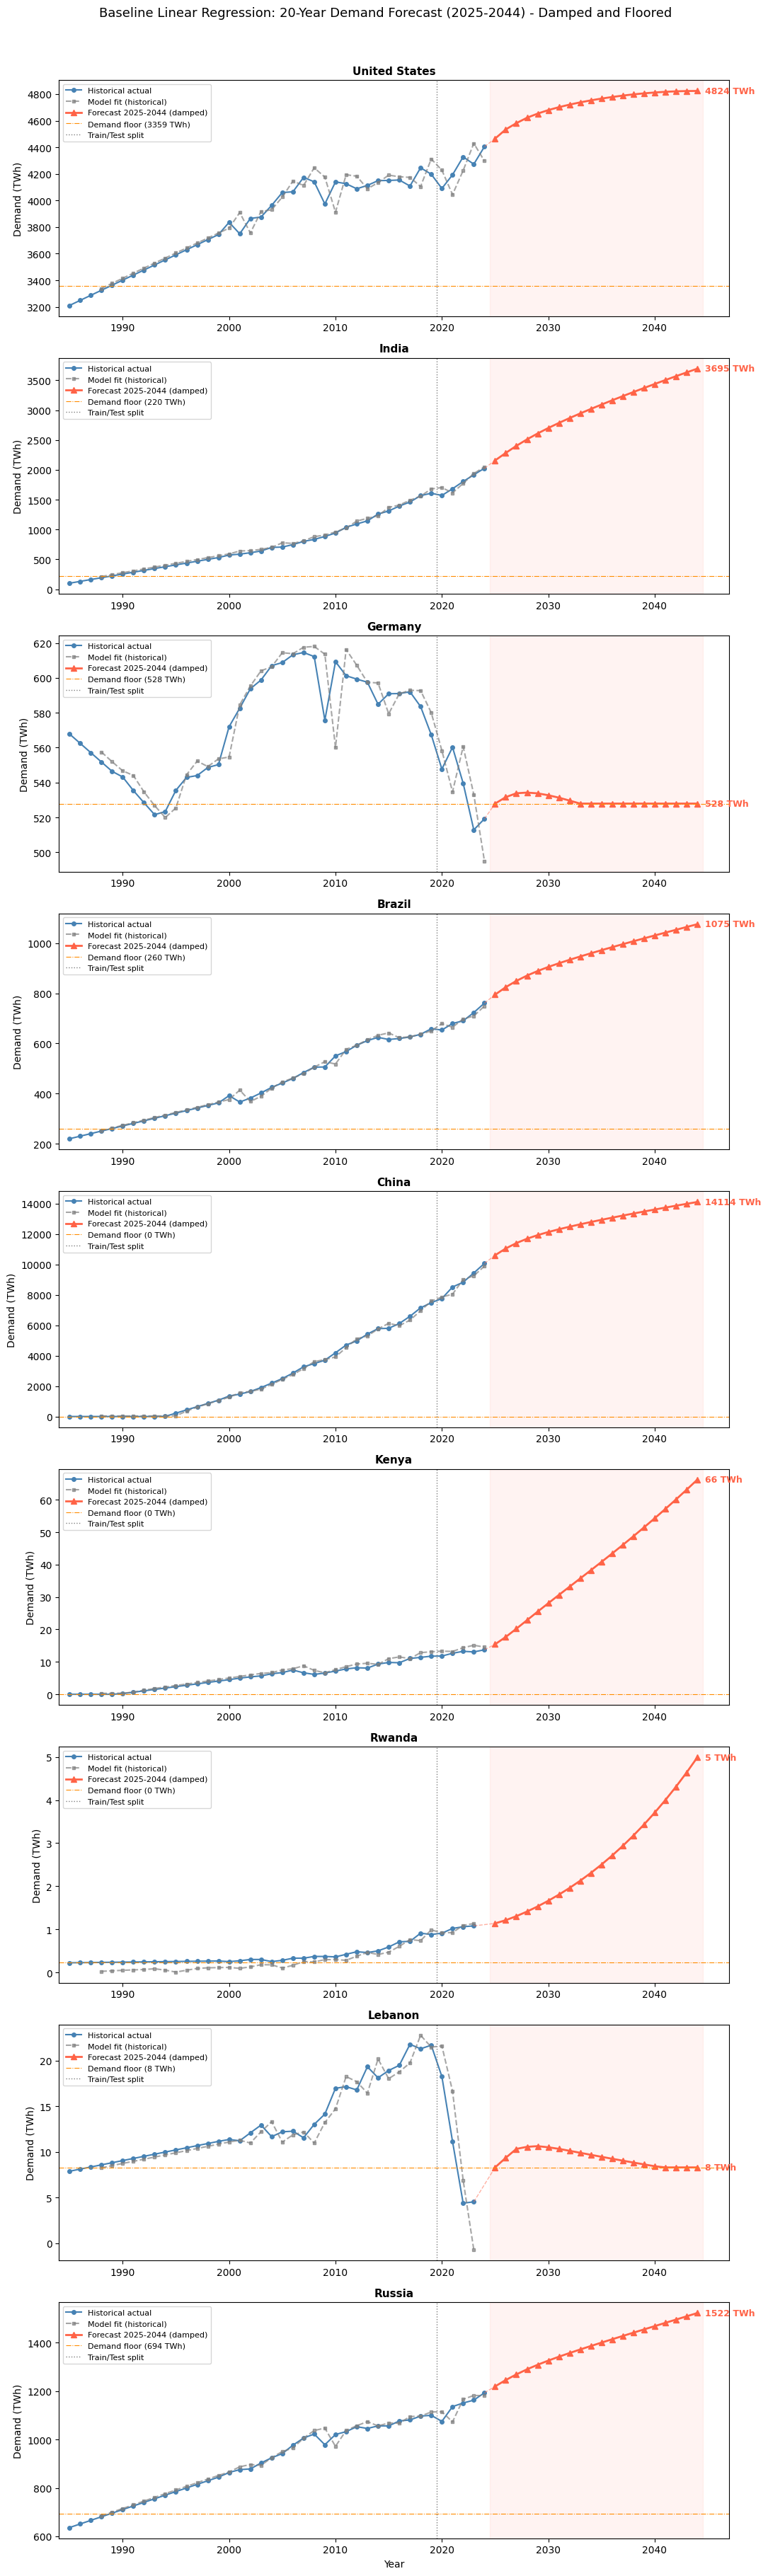

,Country,Year,Forecast (TWh)
0,United States,2025,4465.22
1,United States,2026,4533.99
2,United States,2027,4581.40
3,United States,2028,4621.94
4,United States,2029,4653.14
...,...,...,...
175,Russia,2040,1467.98
176,Russia,2041,1481.47
177,Russia,2042,1494.96
178,Russia,2043,1508.46


In [91]:
# 10-Year Future Forecast with Trend Damping and Floor Correction
#
# Problem: countries with a recent downward trend (e.g. Lebanon, Germany)
# will produce an ever-declining forecast because the autoregressive lag
# features keep compounding the negative momentum.
#
# Fix applied:
#   1. DAMPING    - the yoy_change signal decays toward 0 each step
#   2. FLOOR      - predictions are clipped to the country's historical minimum
#   3. REVERSION  - yoy_change is nudged slightly toward 0 each year

FORECAST_COUNTRIES = ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']
FORECAST_HORIZON = 20  # years ahead
LAST_DATA_YEAR = int(df['year'].max())
EXOG_TREND_YEARS = 5
DAMPING_FACTOR = 0.80  # yoy_change multiplied by this each step (0.80 = 20% decay per year)
FLOOR_PERCENTILE = 10  # forecast floor = this percentile of historical demand

def cagr_extrapolate(series, years_back, horizon):
    tail = series.dropna().iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        return [float(series.dropna().iloc[-1])] * horizon
    rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    last = float(tail.iloc[-1])
    return [last * (1 + rate) ** t for t in range(1, horizon + 1)]

forecast_records = {}
missing = []

for country in FORECAST_COUNTRIES:
    cdf = df[df['country'] == country].sort_values('year').copy()

    if cdf.empty or cdf[TARGET].dropna().empty:
        missing.append(country)
        continue

    known_demand = cdf[TARGET].dropna()

    hist_floor = float(np.percentile(known_demand.values, FLOOR_PERCENTILE))
    hist_floor = max(hist_floor, 0.0)

    lag1 = float(known_demand.iloc[-1])
    lag2 = float(known_demand.iloc[-2]) if len(known_demand) >= 2 else lag1
    lag3 = float(known_demand.iloc[-3]) if len(known_demand) >= 3 else lag2
    yoy = lag1 - lag2

    future_gdp = cagr_extrapolate(cdf['gdp'], EXOG_TREND_YEARS, FORECAST_HORIZON)
    future_pop = cagr_extrapolate(cdf['population'], EXOG_TREND_YEARS, FORECAST_HORIZON)

    future_years = list(range(LAST_DATA_YEAR + 1, LAST_DATA_YEAR + FORECAST_HORIZON + 1))
    future_demand = []

    for t in range(FORECAST_HORIZON):
        gdp_pc = future_gdp[t] / future_pop[t] if future_pop[t] > 0 else 0

        X_step = pd.DataFrame([{
            'demand_lag1': lag1,
            'demand_lag2': lag2,
            'demand_lag3': lag3,
            'demand_yoy_change': yoy,
            'gdp': future_gdp[t],
            'population': future_pop[t],
            'gdp_per_capita': gdp_pc,
        }])

        pred = float(model.predict(X_step)[0])
        pred = max(pred, hist_floor)
        future_demand.append(pred)

        raw_yoy = pred - lag1
        yoy = raw_yoy * (DAMPING_FACTOR ** (t + 1))

        lag3 = lag2
        lag2 = lag1
        lag1 = pred

    forecast_records[country] = {
        'years': future_years,
        'demand': future_demand,
        'floor': hist_floor,
    }

if missing:
    print(f"Warning - not found in dataset: {missing}")
print(f"Forecast ready for: {list(forecast_records.keys())}")
print(f"Damping factor: {DAMPING_FACTOR} | Floor percentile: {FLOOR_PERCENTILE}th")

fig, axes = plt.subplots(len(forecast_records), 1, figsize=(11, 4 * len(forecast_records)), sharex=False)
if len(forecast_records) == 1:
    axes = [axes]

for ax, (country, fc) in zip(axes, forecast_records.items()):
    cdf_plot = df[df['country'] == country].sort_values('year')
    hist = cdf_plot[['year', TARGET]].dropna()

    ax.plot(hist['year'], hist[TARGET], 'o-', color='steelblue', label='Historical actual', markersize=4, linewidth=1.5)

    cdf_model = df_model[df_model['country'] == country].copy()
    if not cdf_model.empty:
        cdf_model['fitted'] = model.predict(cdf_model[FEATURE_COLS])
        ax.plot(cdf_model['year'], cdf_model['fitted'], 's--', color='gray', label='Model fit (historical)', markersize=3, alpha=0.7)

    ax.plot([int(hist['year'].iloc[-1]), fc['years'][0]],
            [float(hist[TARGET].iloc[-1]), fc['demand'][0]],
            '--', color='tomato', linewidth=1, alpha=0.5)

    ax.plot(fc['years'], fc['demand'], '^-', color='tomato',
            label=f"Forecast {fc['years'][0]}-{fc['years'][-1]} (damped)",
            markersize=6, linewidth=2)

    ax.axhline(fc['floor'], color='darkorange', linestyle='-.', linewidth=0.8,
               label=f"Demand floor ({fc['floor']:.0f} TWh)")
    ax.axvspan(fc['years'][0] - 0.5, fc['years'][-1] + 0.5, alpha=0.07, color='tomato')
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1, label='Train/Test split')
    ax.annotate(f"{fc['demand'][-1]:.0f} TWh",
                xy=(fc['years'][-1], fc['demand'][-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='tomato', va='center', fontweight='bold')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(int(hist['year'].min()) - 1, fc['years'][-1] + 3)

axes[-1].set_xlabel('Year')
fig.suptitle(
    f"Baseline Linear Regression: {FORECAST_HORIZON}-Year Demand Forecast "
    f"({LAST_DATA_YEAR+1}-{LAST_DATA_YEAR+FORECAST_HORIZON}) - Damped and Floored",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

summary_rows = []
for country, fc in forecast_records.items():
    for yr, demand in zip(fc['years'], fc['demand']):
        summary_rows.append({'Country': country, 'Year': yr, 'Forecast (TWh)': round(demand, 2)})

forecast_table = pd.DataFrame(summary_rows)
forecast_table


---
# SARIMAX Model

Per-country **ARIMAX** (SARIMAX with no seasonal component  annual data).  
Exogenous variables: `gdp`, `population`  
Order selection: AIC grid search over p∈{0,1,2}, d∈{0,1}, q∈{0,1,2}  
Same train/test split as Linear Regression baseline for direct comparison.

In [92]:
import warnings
from itertools import product as iterproduct
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

EXOG_COLS = ['gdp', 'population']
MIN_TRAIN_OBS = 10


In [93]:
# Re-use df (original cleaned dataframe, before lag engineering)
df_sarimax = df.dropna(subset=[TARGET] + EXOG_COLS).copy()
df_sarimax = df_sarimax.sort_values(['country', 'year'])

train_counts = (
    df_sarimax[df_sarimax['year'] <= TRAIN_END]
    .groupby('country')[TARGET].count()
)
valid_countries = train_counts[train_counts >= MIN_TRAIN_OBS].index.tolist()
df_sarimax = df_sarimax[df_sarimax['country'].isin(valid_countries)].copy()

print(f'Countries included : {df_sarimax["country"].nunique()}')
print(f'Total usable rows  : {len(df_sarimax)}')


Countries included : 180
Total usable rows  : 6981


In [94]:
def select_order(endog, exog, p_range=(0, 1, 2), d_range=(0, 1), q_range=(0, 1, 2)):
    """Grid-search ARIMA(p,d,q) by AIC. Falls back to (1,1,0) on failure."""
    best_aic, best_order = np.inf, (1, 1, 0)
    for p, d, q in iterproduct(p_range, d_range, q_range):
        try:
            res = SARIMAX(endog, exog=exog, order=(p, d, q), trend='c',
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if res.aic < best_aic:
                best_aic, best_order = res.aic, (p, d, q)
        except Exception:
            continue
    return best_order


In [95]:
sarimax_rows = []
fitted_models = {}  # {country: (fitted_result, full_cdf, forecast_series)}

countries_s = sorted(df_sarimax['country'].unique())

for i, country in enumerate(countries_s):
    cdf = df_sarimax[df_sarimax['country'] == country].copy().set_index('year')
    train_c = cdf[cdf.index <= TRAIN_END]
    test_c  = cdf[cdf.index >= TEST_START]

    if len(test_c) == 0:
        continue

    endog_train = train_c[TARGET]
    exog_train = train_c[EXOG_COLS]
    exog_test = test_c[EXOG_COLS]

    order = select_order(endog_train, exog_train)

    try:
        fitted = SARIMAX(endog_train, exog=exog_train, order=order, trend='c',
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    except Exception as e:
        print(f'  [WARN] {country}: fit failed  {e}')
        continue

    try:
        forecast = fitted.forecast(steps=len(test_c), exog=exog_test)
    except Exception as e:
        print(f'  [WARN] {country}: forecast failed  {e}')
        continue

    fitted_models[country] = (fitted, cdf, forecast)

    y_true = test_c[TARGET].values
    y_pred = forecast.values
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))

    for yr, actual, pred in zip(test_c.index, y_true, y_pred):
        sarimax_rows.append({
            'country': country, 'year': int(yr),
            'actual': actual, 'predicted': pred,
            'order': str(order), 'test_rmse': rmse, 'test_mae': mae
        })

    if (i + 1) % 20 == 0 or (i + 1) == len(countries_s):
        print(f'  Processed {i+1}/{len(countries_s)} countries...')

sarimax_results = pd.DataFrame(sarimax_rows)
print(f'\nDone. Forecasts for {sarimax_results["country"].nunique()} countries.')


  Processed 20/180 countries...
  Processed 40/180 countries...
  Processed 60/180 countries...
  Processed 80/180 countries...
  Processed 100/180 countries...
  Processed 120/180 countries...
  Processed 140/180 countries...
  Processed 160/180 countries...
  Processed 180/180 countries...

Done. Forecasts for 180 countries.


In [96]:
sarimax_test_rmse = float(np.sqrt(mean_squared_error(
    sarimax_results['actual'], sarimax_results['predicted'])))
sarimax_test_mae  = float(mean_absolute_error(
    sarimax_results['actual'], sarimax_results['predicted']))

print('-' * 52)
print(f'Linear Regression  Test RMSE: {test_rmse:.3f} | MAE: {test_mae:.3f}')
print(f'SARIMAX Test RMSE: {sarimax_test_rmse:.3f} | MAE: {sarimax_test_mae:.3f}')
print('-' * 52)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 'Test RMSE': round(test_rmse, 3), 'Test MAE': round(test_mae, 3)},
    {'Model': 'SARIMAX', 'Test RMSE': round(sarimax_test_rmse, 3), 'Test MAE': round(sarimax_test_mae, 3)},
])
comparison


----------------------------------------------------
Linear Regression  Test RMSE: 23.986 | MAE: 5.263
SARIMAX Test RMSE: 63.153 | MAE: 7.552
----------------------------------------------------


,Model,Test RMSE,Test MAE
0,Linear Regression,23.986,5.263
1,SARIMAX,63.153,7.552


In [97]:
# Per-country SARIMAX metrics
sx_country = (
    sarimax_results.drop_duplicates('country')[['country', 'order', 'test_rmse', 'test_mae']]
    .rename(columns={'test_rmse': 'SARIMAX_RMSE', 'test_mae': 'SARIMAX_MAE'})
)

# Merge with Linear Regression per-country metrics
lr_country = country_metrics[['country', 'RMSE', 'MAE']].rename(
    columns={'RMSE': 'LR_RMSE', 'MAE': 'LR_MAE'}
)

comparison_country = sx_country.merge(lr_country, on='country', how='left')
comparison_country['RMSE_improvement'] = (
    (comparison_country['LR_RMSE'] - comparison_country['SARIMAX_RMSE'])
    / comparison_country['LR_RMSE'] * 100
).round(1)

comparison_country = comparison_country.sort_values('SARIMAX_RMSE', ascending=False).reset_index(drop=True)
comparison_country.columns = ['Country', 'ARIMA Order', 'SARIMAX RMSE', 'SARIMAX MAE',
                               'LR RMSE', 'LR MAE', 'RMSE Improv. (%)']
print('Top 15 countries by SARIMAX RMSE:')
comparison_country.head(15)


Top 15 countries by SARIMAX RMSE:


,Country,ARIMA Order,SARIMAX RMSE,SARIMAX MAE,LR RMSE,LR MAE,RMSE Improv. (%)
0,China,"(0, 1, 2)",789.136152,603.505235,256.924,222.675,-207.1
1,India,"(0, 1, 2)",139.439568,103.386150,69.984,55.558,-99.2
2,United States,"(0, 1, 2)",69.714288,58.144413,132.332,130.543,47.3
3,Russia,"(2, 1, 2)",44.942467,40.800942,35.483,29.834,-26.7
4,Brazil,"(0, 1, 2)",38.133950,27.908317,15.857,14.733,-140.5
5,France,"(0, 1, 2)",33.839104,29.163877,24.549,23.333,-37.8
6,Iran,"(0, 1, 2)",25.203453,23.479499,7.158,6.303,-252.1
7,Indonesia,"(0, 1, 2)",24.294620,18.842376,11.294,9.260,-115.1
8,Germany,"(0, 1, 2)",21.428948,18.006720,20.977,20.311,-2.2
9,Pakistan,"(0, 1, 1)",20.680441,19.047186,8.112,6.976,-154.9


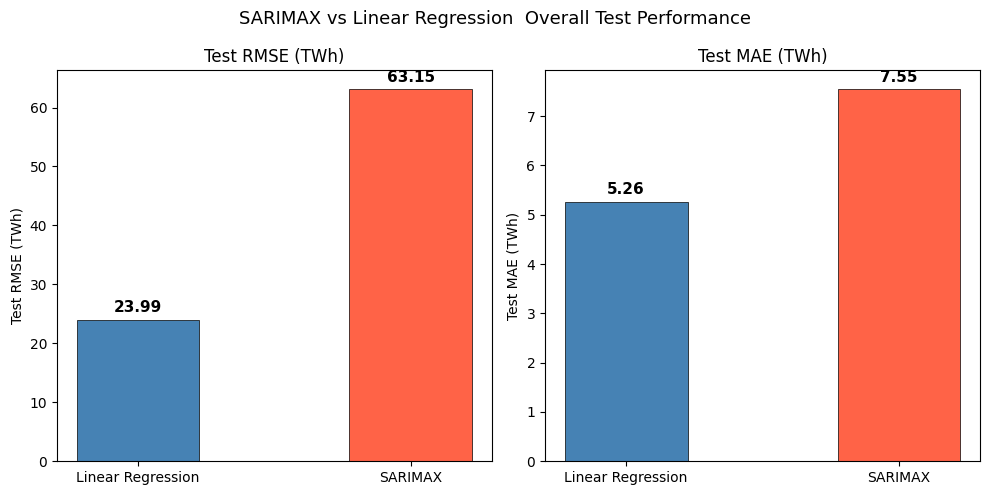

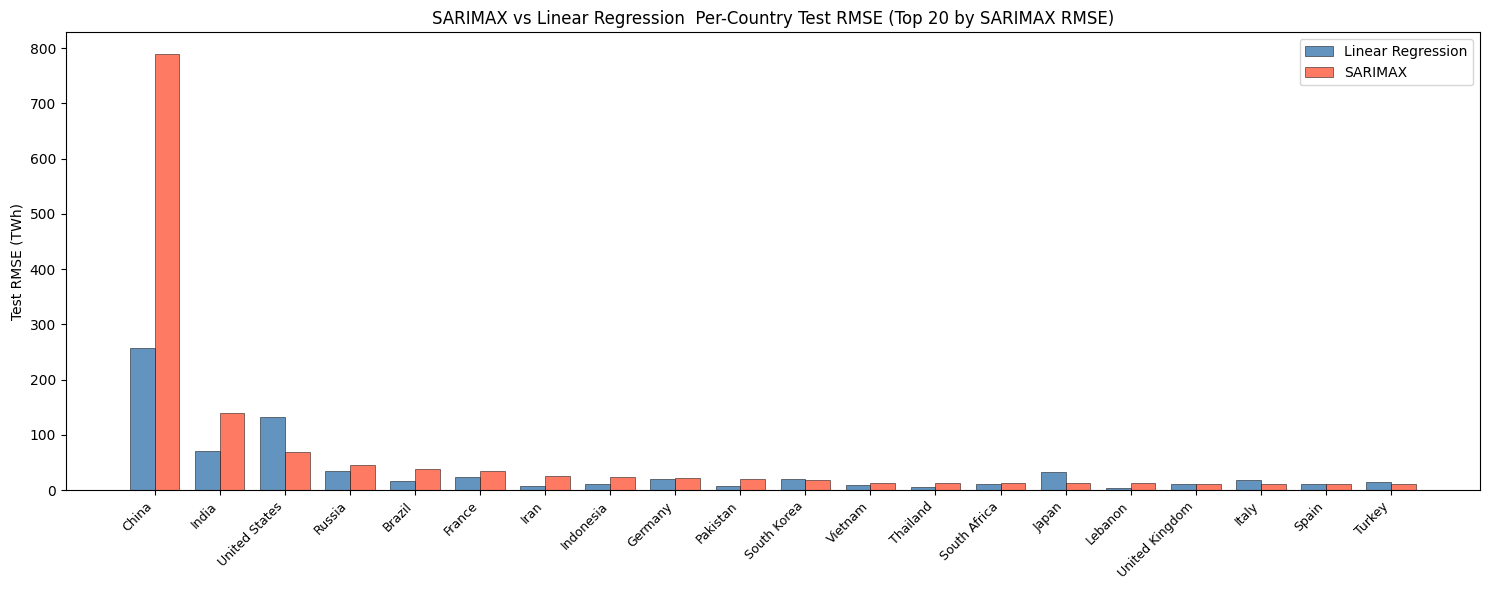

<Figure size 640x480 with 0 Axes>

In [98]:
# Side-by-side RMSE & MAE comparison: SARIMAX vs Linear Regression
# Overall comparison bar chart
labels    = ['Linear Regression', 'SARIMAX']
rmse_vals = [test_rmse, sarimax_test_rmse]
mae_vals  = [test_mae,  sarimax_test_mae]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['steelblue', 'tomato']

for ax, vals, metric in zip(axes, [rmse_vals, mae_vals], ['Test RMSE (TWh)', 'Test MAE (TWh)']):
    bars = ax.bar(labels, vals, width=0.45, color=colors, edgecolor='k', linewidth=0.5)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02 * max(vals),
                f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('SARIMAX vs Linear Regression  Overall Test Performance', fontsize=13)
plt.tight_layout()
plt.show()

# Per-country RMSE comparison (top 20 worst by SARIMAX)
top20 = comparison_country.head(20).copy()

x     = np.arange(len(top20))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
bars_lr = ax.bar(x - width/2, top20['LR RMSE'],      width, label='Linear Regression',
                  color='steelblue', alpha=0.85, edgecolor='k', linewidth=0.4)
bars_sx = ax.bar(x + width/2, top20['SARIMAX RMSE'], width, label='SARIMAX',
                  color='tomato',    alpha=0.85, edgecolor='k', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(top20['Country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Test RMSE (TWh)')
ax.set_title('SARIMAX vs Linear Regression  Per-Country Test RMSE (Top 20 by SARIMAX RMSE)')
ax.legend()
plt.tight_layout()
plt.show()

# Per-country MAE comparison (top 20 worst by SARIMAX)fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width/2, top20['LR MAE'],      width, label='Linear Regression',
       color='steelblue', alpha=0.85, edgecolor='k', linewidth=0.4)
ax.bar(x + width/2, top20['SARIMAX MAE'], width, label='SARIMAX',
       color='tomato',    alpha=0.85, edgecolor='k', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(top20['Country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Test MAE (TWh)')
ax.set_title('SARIMAX vs Linear Regression  Per-Country Test MAE (Top 20 by SARIMAX RMSE)')
ax.legend()
plt.tight_layout()
plt.show()


Forecast ready for: ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']


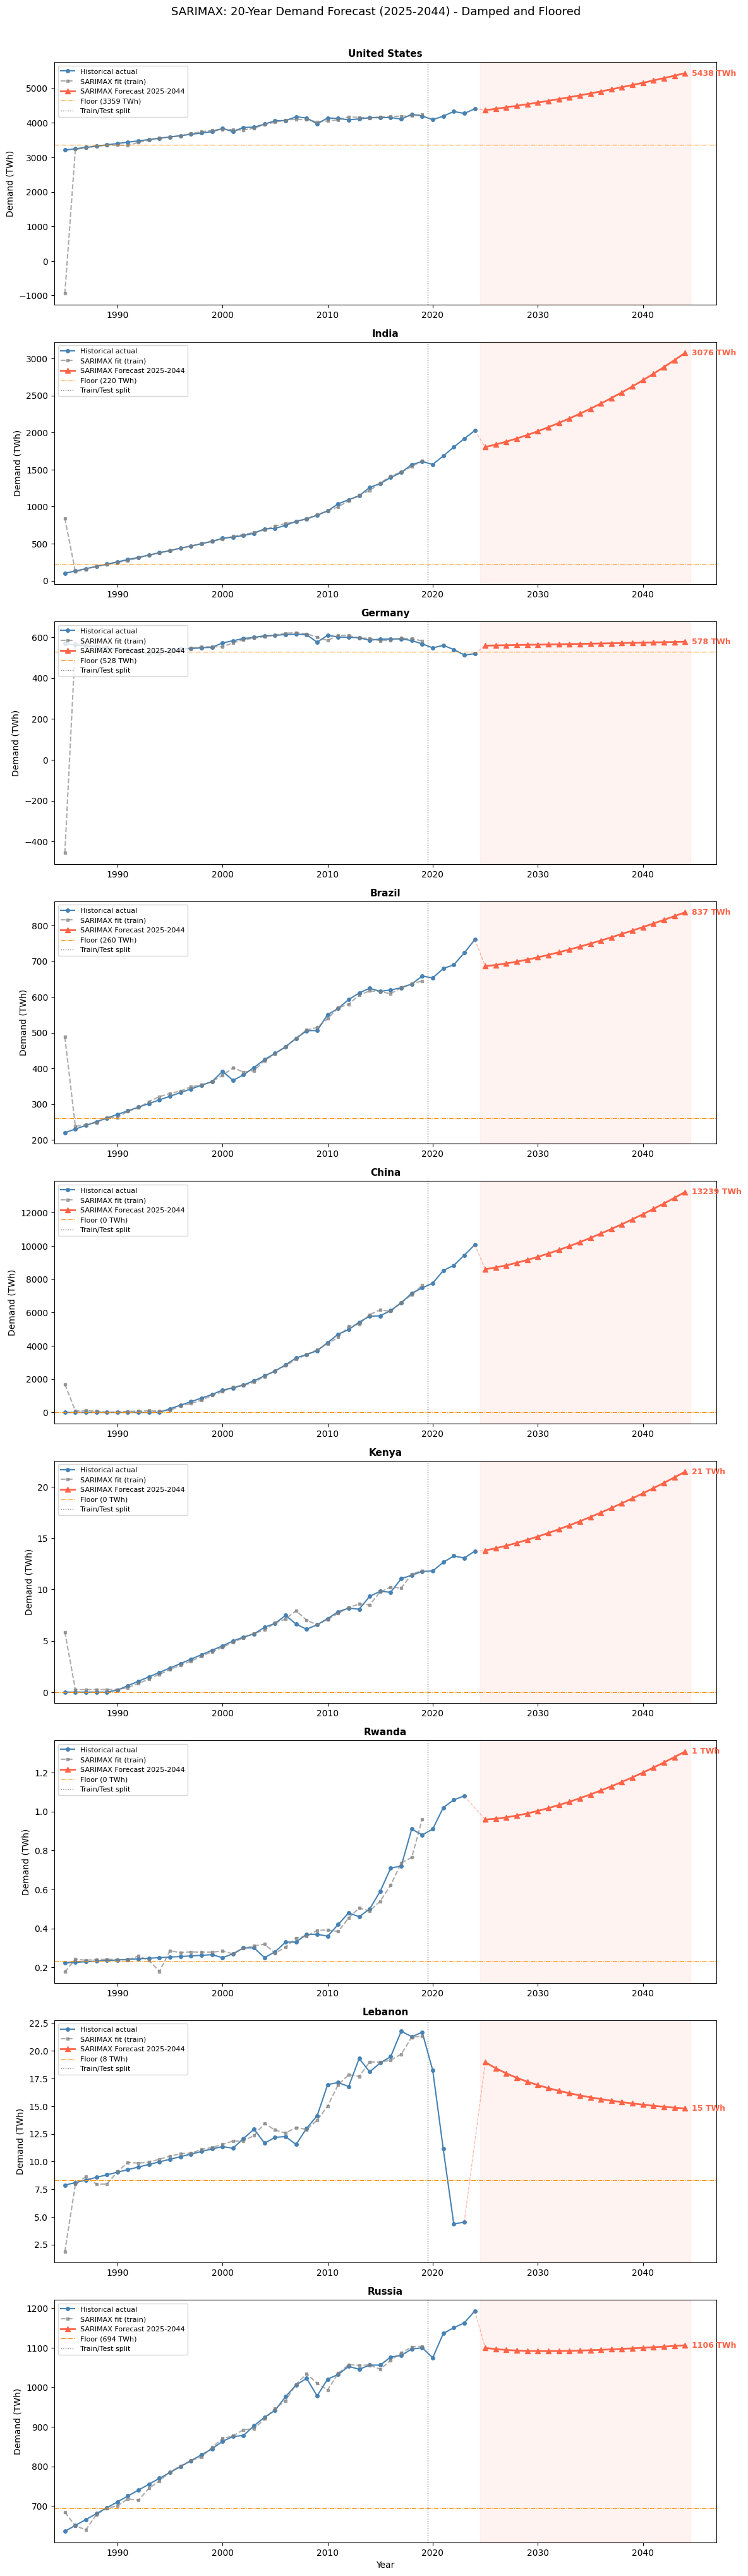

,Country,Year,SARIMAX Forecast (TWh)
0,United States,2025,4365.89
1,United States,2026,4406.87
2,United States,2027,4449.41
3,United States,2028,4493.62
4,United States,2029,4539.57
...,...,...,...
175,Russia,2040,1099.78
176,Russia,2041,1101.26
177,Russia,2042,1102.80
178,Russia,2043,1104.39


In [99]:
# SARIMAX 20-Year Forecast with Trend Damping and Floor

FORECAST_COUNTRIES_SX = [
    'United States', 'India', 'Germany', 'Brazil', 'China',
    'Kenya', 'Rwanda', 'Lebanon', 'Russia'
]
FORECAST_HORIZON_SX = 20
LAST_DATA_YEAR_SX = int(df['year'].max())
EXOG_TREND_YEARS_SX = 5
DAMPING_FACTOR_SX = 0.80
FLOOR_PERCENTILE_SX = 10

def cagr_extrap(series, years_back, horizon):
    tail = series.dropna().iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        v = float(series.dropna().iloc[-1])
        return [v] * horizon
    rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    last = float(tail.iloc[-1])
    return [last * (1 + rate) ** t for t in range(1, horizon + 1)]

sx_forecast_records = {}
sx_missing = []

for country in FORECAST_COUNTRIES_SX:
    if country not in fitted_models:
        sx_missing.append(country)
        continue

    fitted_result, cdf_idx, _ = fitted_models[country]

    cdf_full = df[df['country'] == country].sort_values('year')
    known_demand = cdf_full[TARGET].dropna()
    hist_floor = max(float(np.percentile(known_demand.values, FLOOR_PERCENTILE_SX)), 0.0)

    future_gdp = cagr_extrap(cdf_full['gdp'], EXOG_TREND_YEARS_SX, FORECAST_HORIZON_SX)
    future_pop = cagr_extrap(cdf_full['population'], EXOG_TREND_YEARS_SX, FORECAST_HORIZON_SX)

    future_years = list(range(LAST_DATA_YEAR_SX + 1, LAST_DATA_YEAR_SX + FORECAST_HORIZON_SX + 1))
    future_demand = []

    current_fitted = fitted_result
    prev_pred = float(known_demand.iloc[-1])

    for t in range(FORECAST_HORIZON_SX):
        exog_step = pd.DataFrame(
            [[future_gdp[t], future_pop[t]]],
            columns=EXOG_COLS,
            index=[future_years[t]]
        )
        try:
            fc_step = current_fitted.forecast(steps=1, exog=exog_step)
            pred = float(fc_step.iloc[0])
        except Exception:
            pred = prev_pred

        pred = max(pred, hist_floor)

        try:
            new_endog = pd.Series([pred], index=[future_years[t]])
            current_fitted = current_fitted.append(new_endog, exog=exog_step, refit=False)
        except Exception:
            pass

        future_demand.append(pred)

        hist_mean = float(known_demand.mean())
        blend_w = 1 - (DAMPING_FACTOR_SX ** (t + 1))
        pred_damped = pred * (1 - blend_w * 0.15) + hist_mean * (blend_w * 0.15)
        pred_damped = max(pred_damped, hist_floor)
        future_demand[-1] = pred_damped

        prev_pred = pred_damped

    sx_forecast_records[country] = {
        'years': future_years,
        'demand': future_demand,
        'floor': hist_floor,
    }

if sx_missing:
    print(f'Warning - not found or not fitted: {sx_missing}')
print(f'Forecast ready for: {list(sx_forecast_records.keys())}')

n_countries = len(sx_forecast_records)
fig, axes = plt.subplots(n_countries, 1, figsize=(12, 4.5 * n_countries), sharex=False)
if n_countries == 1:
    axes = [axes]

for ax, (country, fc) in zip(axes, sx_forecast_records.items()):
    cdf_plot = df[df['country'] == country].sort_values('year')
    hist = cdf_plot[['year', TARGET]].dropna()

    ax.plot(hist['year'], hist[TARGET], 'o-', color='steelblue', label='Historical actual', markersize=4, linewidth=1.5)

    if country in fitted_models:
        fitted_res, cdf_idx, _ = fitted_models[country]
        in_sample = fitted_res.fittedvalues
        ax.plot(in_sample.index, in_sample.values, 's--', color='gray', label='SARIMAX fit (train)', markersize=3, alpha=0.65)

    ax.plot([int(hist['year'].iloc[-1]), fc['years'][0]],
            [float(hist[TARGET].iloc[-1]), fc['demand'][0]],
            '--', color='tomato', linewidth=1, alpha=0.45)

    ax.plot(fc['years'], fc['demand'], '^-', color='tomato',
            label=f"SARIMAX Forecast {fc['years'][0]}-{fc['years'][-1]}",
            markersize=6, linewidth=2)

    ax.axhline(fc['floor'], color='darkorange', linestyle='-.', linewidth=0.8,
               label=f"Floor ({fc['floor']:.0f} TWh)")
    ax.axvspan(fc['years'][0] - 0.5, fc['years'][-1] + 0.5, alpha=0.07, color='tomato')
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1, label='Train/Test split')
    ax.annotate(f"{fc['demand'][-1]:.0f} TWh",
                xy=(fc['years'][-1], fc['demand'][-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='tomato', va='center', fontweight='bold')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(int(hist['year'].min()) - 1, fc['years'][-1] + 3)

axes[-1].set_xlabel('Year')
fig.suptitle(
    f"SARIMAX: 20-Year Demand Forecast ({LAST_DATA_YEAR_SX+1}-{LAST_DATA_YEAR_SX+FORECAST_HORIZON_SX}) - Damped and Floored",
    fontsize=13, y=1.005
)
plt.tight_layout()
plt.show()

sx_summary_rows = []
for country, fc in sx_forecast_records.items():
    for yr, demand in zip(fc['years'], fc['demand']):
        sx_summary_rows.append({'Country': country, 'Year': yr, 'SARIMAX Forecast (TWh)': round(demand, 2)})
pd.DataFrame(sx_summary_rows)


---
# LSTM Model

A **global windowed LSTM** trained across all countries simultaneously.
Each training sample is a sliding window of `SEQ_LEN` consecutive years of features,
predicting the next year's demand. Country identity is encoded via an embedding layer.

**Why global (not per-country)?**  
With ~34 training years per country, a per-country LSTM would overfit severely.
Training across all 181 countries gives ~5,000+ windows and lets the model learn
shared patterns (e.g. how post-crisis recoveries typically unfold  relevant for Lebanon).

**Architecture:**  
- Country embedding → concatenated with scaled features → LSTM → Dense output  
- Features: `demand_lag1/2/3`, `demand_yoy_change`, `gdp`, `population`, `gdp_per_capita`  
- Train: 19852019 | Test: 20202024

In [100]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Dense, LSTM,
    Concatenate, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')


TensorFlow version: 2.21.0


In [161]:
SEQ_LEN = 5        # years of history fed into LSTM per prediction step
EMBED_DIM = 8      # country embedding dimension
LSTM_UNITS = 64
DROPOUT_RATE = 0.2
BATCH_SIZE = 64
MAX_EPOCHS = 150
LEARNING_RATE = 1e-3

LSTM_FEATURES = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

# df_model already has all rows with valid features (built in the baseline section)
all_countries = sorted(df_model['country'].unique())
country_to_idx = {c: i for i, c in enumerate(all_countries)}
N_COUNTRIES = len(all_countries)

df_lstm = df_model.copy()
df_lstm['country_idx'] = df_lstm['country'].map(country_to_idx)

print(f'Countries : {N_COUNTRIES}')
print(f'Total rows: {len(df_lstm)}')
print(f'Features  : {LSTM_FEATURES}')


Countries : 181
Total rows: 6451
Features  : ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [162]:
# Fit scaler on TRAIN only to avoid leakage
train_mask = df_lstm['year'] <= TRAIN_END
test_mask = df_lstm['year'] >= TEST_START

feat_scaler = StandardScaler()
target_scaler = StandardScaler()

df_lstm.loc[train_mask, LSTM_FEATURES] = feat_scaler.fit_transform(
    df_lstm.loc[train_mask, LSTM_FEATURES]
)
df_lstm.loc[test_mask, LSTM_FEATURES] = feat_scaler.transform(
    df_lstm.loc[test_mask, LSTM_FEATURES]
)

df_lstm['target_scaled'] = target_scaler.fit_transform(df_lstm[[TARGET]])

print('Scaling done. Train scaler fit on', train_mask.sum(), 'rows.')


Scaling done. Train scaler fit on 5623 rows.


In [163]:
# Build sliding windows -> # For each country, slide a window of SEQ_LEN years across the time series.
# Each window produces one (X_seq, country_idx, y) training sample.
# Windows that straddle the train/test boundary are excluded from training.

def make_windows(df_c, seq_len, feature_cols, target_col='target_scaled'):
    """
    Returns:
        X_seq       : (n_windows, seq_len, n_features)
        country_ids : (n_windows,)  same country index repeated
        y           : (n_windows,)  scaled target for the step after the window
    """
    vals   = df_c[feature_cols].values       # (T, F)
    tgt    = df_c[target_col].values         # (T,)
    cidx   = int(df_c['country_idx'].iloc[0])
    years  = df_c['year'].values

    X_seq, cids, ys, yrs_out = [], [], [], []
    for i in range(seq_len, len(vals)):
        X_seq.append(vals[i - seq_len : i])
        cids.append(cidx)
        ys.append(tgt[i])
        yrs_out.append(years[i])

    if not X_seq:
        return None
    return (np.array(X_seq, dtype=np.float32),
            np.array(cids,  dtype=np.int32),
            np.array(ys,    dtype=np.float32),
            np.array(yrs_out))

train_X, train_C, train_y = [], [], []
test_X,  test_C,  test_y  = [], [], []
test_meta = []   # (country, year) for per-country evaluation

for country in all_countries:
    cdf = df_lstm[df_lstm['country'] == country].sort_values('year').reset_index(drop=True)

    # TRAIN windows: window entirely within train period
    cdf_train = cdf[cdf['year'] <= TRAIN_END]
    out_train = make_windows(cdf_train, SEQ_LEN, LSTM_FEATURES)
    if out_train:
        Xs, Cs, ys, _ = out_train
        train_X.append(Xs); train_C.append(Cs); train_y.append(ys)

    # TEST windows: use ALL available data up to each test year
    # The window uses the SEQ_LEN years before each test year
    cdf_all = cdf.reset_index(drop=True)
    test_years = cdf_all[cdf_all['year'] >= TEST_START]['year'].values
    cidx = country_to_idx[country]

    for yr in test_years:
        # Get the SEQ_LEN rows ending just before this year's prediction
        preceding = cdf_all[cdf_all['year'] < yr].tail(SEQ_LEN)
        if len(preceding) < SEQ_LEN:
            continue
        row_target = cdf_all[cdf_all['year'] == yr]
        if row_target.empty:
            continue
        X_win = preceding[LSTM_FEATURES].values.astype(np.float32)
        y_val = float(row_target['target_scaled'].iloc[0])
        test_X.append(X_win)
        test_C.append(cidx)
        test_y.append(y_val)
        test_meta.append({'country': country, 'year': int(yr),
                          'actual': float(row_target[TARGET].iloc[0])})

train_X = np.concatenate(train_X, axis=0)
train_C = np.concatenate(train_C, axis=0)
train_y = np.concatenate(train_y, axis=0)
test_X  = np.array(test_X,  dtype=np.float32)
test_C  = np.array(test_C,  dtype=np.int32)
test_y  = np.array(test_y,  dtype=np.float32)

print(f'Train windows : {train_X.shape}')
print(f'Test  windows : {test_X.shape}')


Train windows : (4718, 5, 7)
Test  windows : (828, 5, 7)


In [164]:
# Architecture:
#   seq_input  (SEQ_LEN, n_features) -> LSTM(64) -> lstm_out
#   country_id (1,) -> Embedding(8) -> Flatten -> embed_out
#   Concatenate([lstm_out, embed_out]) -> BatchNorm -> Dense(32) -> Dropout -> Dense(1)

n_features = len(LSTM_FEATURES)

seq_input = Input(shape=(SEQ_LEN, n_features), name='seq_input')
lstm_out = LSTM(LSTM_UNITS, name='lstm')(seq_input)

ctry_input = Input(shape=(1,), name='country_input')
embed_out = Embedding(input_dim=N_COUNTRIES, output_dim=EMBED_DIM, name='country_embed')(ctry_input)
embed_out = Flatten()(embed_out)

merged = Concatenate()([lstm_out, embed_out])
x = BatchNormalization()(merged)
x = Dense(32, activation='relu')(x)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(1, name='output')(x)

lstm_model = Model(inputs=[seq_input, ctry_input], outputs=output)
lstm_model.compile(optimizer=Adam(LEARNING_RATE), loss='mse', metrics=['mae'])

lstm_model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ country_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 5, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embed       │ (None, 1, 8)      │      1,448 │ country_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     18,432 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 8)         │          0 │ country_embed[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 72)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72)        │        288 │ concatenate_5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,336 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,537 (88.04 KB)

 Trainable params: 22,393 (87.47 KB)

 Non-trainable params: 144 (576.00 B)

Epoch 1/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5012 - mae: 0.3772 - val_loss: 2.0730 - val_mae: 0.4639 - learning_rate: 0.0010
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1648 - mae: 0.2175 - val_loss: 1.8117 - val_mae: 0.4474 - learning_rate: 0.0010
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0699 - mae: 0.1598 - val_loss: 1.7463 - val_mae: 0.4360 - learning_rate: 0.0010
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0752 - mae: 0.1357 - val_loss: 1.4322 - val_mae: 0.4003 - learning_rate: 0.0010
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0707 - mae: 0.1243 - val_loss: 1.2570 - val_mae: 0.3727 - learning_rate: 0.0010
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0551 - mae: 0.1071 - val_loss: 0.9444 - val_mae: 0.3151 - learning_rate: 0.0010
Epoch 7/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0624 - mae: 0.0930 - val_loss: 0.6596 - val_mae: 0.2661 - learning_rate: 0.0010
Epoch 8/150


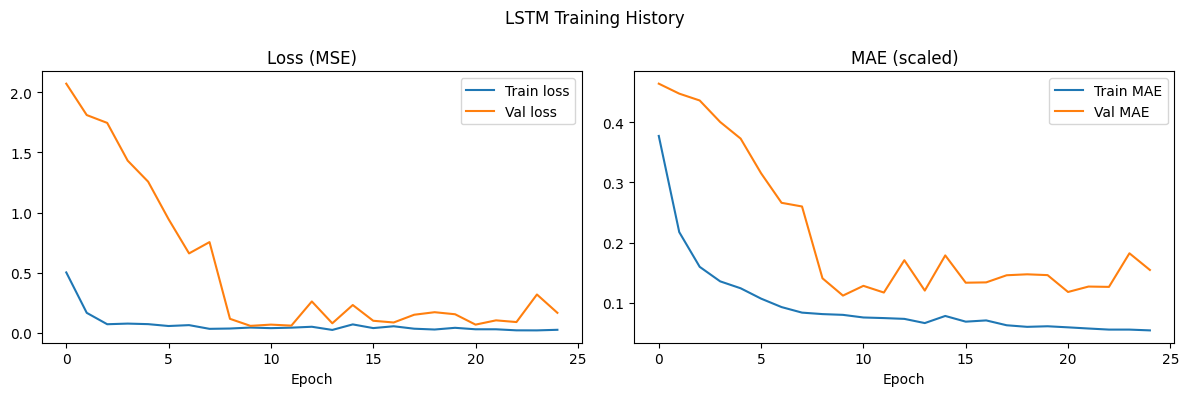

In [165]:
# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1, min_lr=1e-5)
]

history = lstm_model.fit(
    [train_X, train_C], train_y,
    validation_split=0.15,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE (scaled)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('LSTM Training History')
plt.tight_layout()
plt.show()


In [166]:
# Evaluate on test set
test_pred_scaled = lstm_model.predict([test_X, test_C], verbose=0).flatten()

# Inverse-transform predictions and actuals back to TWh
test_pred_twh = target_scaler.inverse_transform(
    test_pred_scaled.reshape(-1, 1)).flatten()

# Build results dataframe
lstm_results = pd.DataFrame(test_meta)
lstm_results['predicted'] = test_pred_twh

# Overall metrics
lstm_test_rmse = float(np.sqrt(mean_squared_error(lstm_results['actual'], lstm_results['predicted'])))
lstm_test_mae  = float(mean_absolute_error(lstm_results['actual'],        lstm_results['predicted']))

print('-' * 55)
print(f'Linear Regression  Test RMSE: {test_rmse:.3f} | MAE: {test_mae:.3f}')
print(f'LSTM               Test RMSE: {lstm_test_rmse:.3f} | MAE: {lstm_test_mae:.3f}')
print('-' * 55)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 'Test RMSE': round(test_rmse, 3), 'Test MAE': round(test_mae, 3)},
    {'Model': 'LSTM', 'Test RMSE': round(lstm_test_rmse, 3), 'Test MAE': round(lstm_test_mae, 3)},
])
comparison


-------------------------------------------------------
Linear Regression  Test RMSE: 23.986 | MAE: 5.263
LSTM               Test RMSE: 108.955 | MAE: 46.792
-------------------------------------------------------


,Model,Test RMSE,Test MAE
0,Linear Regression,23.986,5.263
1,LSTM,108.955,46.792


In [167]:
# Per-country metrics
lstm_country_rows = []
for country in lstm_results['country'].unique():
    mask = lstm_results['country'] == country
    yt   = lstm_results.loc[mask, 'actual']
    yp   = lstm_results.loc[mask, 'predicted']
    lstm_country_rows.append({
        'country': country,
        'LSTM_RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 3),
        'LSTM_MAE': round(float(mean_absolute_error(yt, yp)), 3),
    })

lstm_country_df = pd.DataFrame(lstm_country_rows)

# Merge with LR per-country metrics
lr_country = country_metrics[['country', 'RMSE', 'MAE']].rename(
    columns={'RMSE': 'LR_RMSE', 'MAE': 'LR_MAE'}
)
comparison_country = lstm_country_df.merge(lr_country, on='country', how='left')
comparison_country['RMSE_improvement_%'] = (
    (comparison_country['LR_RMSE'] - comparison_country['LSTM_RMSE'])
    / comparison_country['LR_RMSE'] * 100
).round(1)
comparison_country = comparison_country.sort_values('LSTM_RMSE', ascending=False).reset_index(drop=True)

print('Top 15 countries by LSTM RMSE:')
comparison_country.head(15)


Top 15 countries by LSTM RMSE:


,country,LSTM_RMSE,LSTM_MAE,LR_RMSE,LR_MAE,RMSE_improvement_%
0,United States,795.533,613.706,132.332,130.543,-501.2
1,China,744.783,638.596,256.924,222.675,-189.9
2,India,534.234,501.317,69.984,55.558,-663.4
3,Japan,248.055,243.937,32.488,27.542,-663.5
4,Russia,227.833,220.705,35.483,29.834,-542.1
5,South Korea,218.086,217.172,19.281,14.833,-1031.1
6,Canada,205.277,204.128,8.649,7.851,-2273.4
7,Germany,191.682,191.297,20.977,20.311,-813.8
8,Brazil,171.980,166.144,15.857,14.733,-984.6
9,Saudi Arabia,160.082,152.487,8.935,8.545,-1691.6


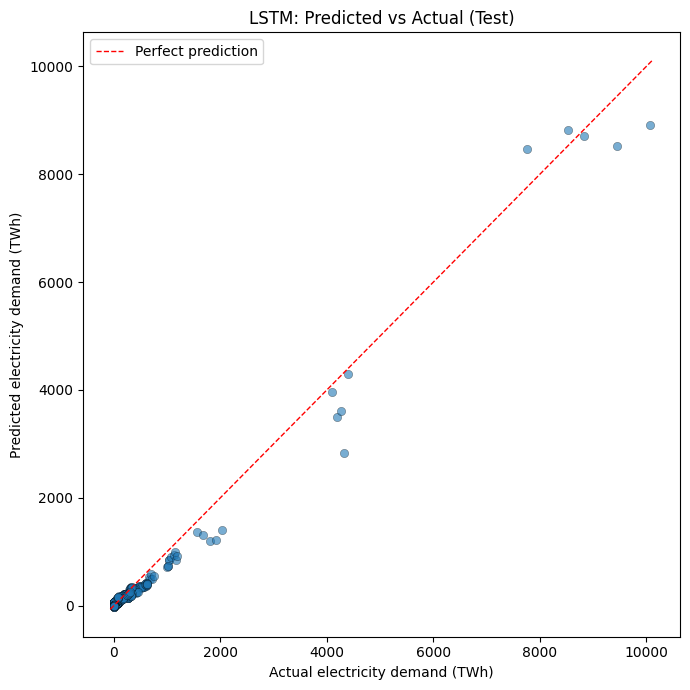

In [168]:
# Plot 1: Predicted vs Actual scatter
plt.figure(figsize=(7, 7))
plt.scatter(lstm_results['actual'], lstm_results['predicted'],
            alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [
    min(lstm_results['actual'].min(), lstm_results['predicted'].min()) - 50,
    max(lstm_results['actual'].max(), lstm_results['predicted'].max()) + 50
]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('LSTM: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()


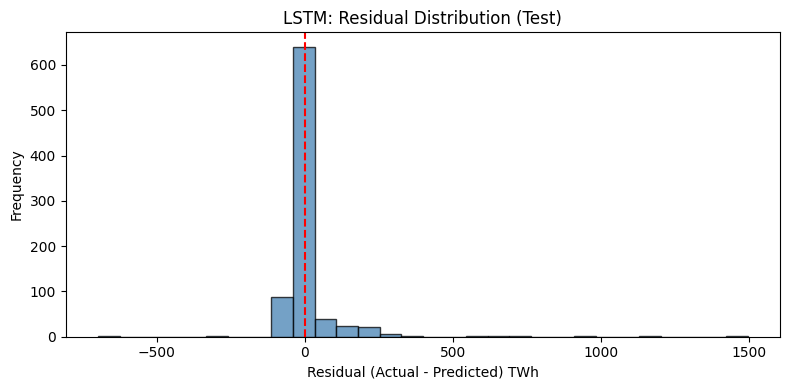

Mean residual : 0.6369 TWh
Std residuals : 108.9528 TWh
Skewness      : 6.6404


In [169]:
# Plot 2: Residual distribution
lstm_residuals = lstm_results['actual'].values - lstm_results['predicted'].values

plt.figure(figsize=(8, 4))
plt.hist(lstm_residuals, bins=30, edgecolor='k', alpha=0.75, color='steelblue')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('LSTM: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

print(f'Mean residual : {lstm_residuals.mean():.4f} TWh')
print(f'Std residuals : {lstm_residuals.std():.4f} TWh')
print(f'Skewness      : {pd.Series(lstm_residuals).skew():.4f}')


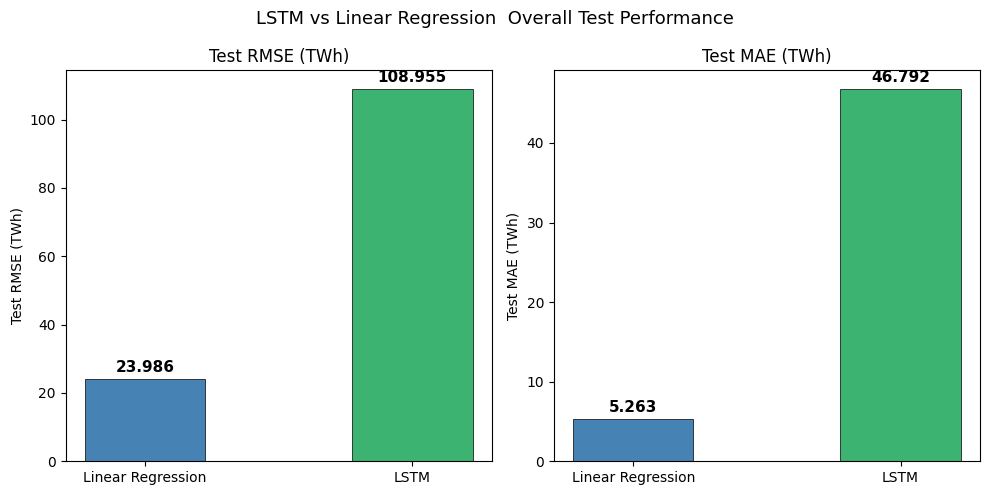

In [170]:
# Plot 3: Overall RMSE & MAE comparison bar chart
labels    = ['Linear Regression', 'LSTM']
rmse_vals = [test_rmse, lstm_test_rmse]
mae_vals  = [test_mae,  lstm_test_mae]
colors    = ['steelblue', 'mediumseagreen']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, vals, metric in zip(axes, [rmse_vals, mae_vals], ['Test RMSE (TWh)', 'Test MAE (TWh)']):
    bars = ax.bar(labels, vals, width=0.45, color=colors, edgecolor='k', linewidth=0.5)
    ax.set_ylabel(metric); ax.set_title(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02 * max(vals),
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('LSTM vs Linear Regression  Overall Test Performance', fontsize=13)
plt.tight_layout()
plt.show()


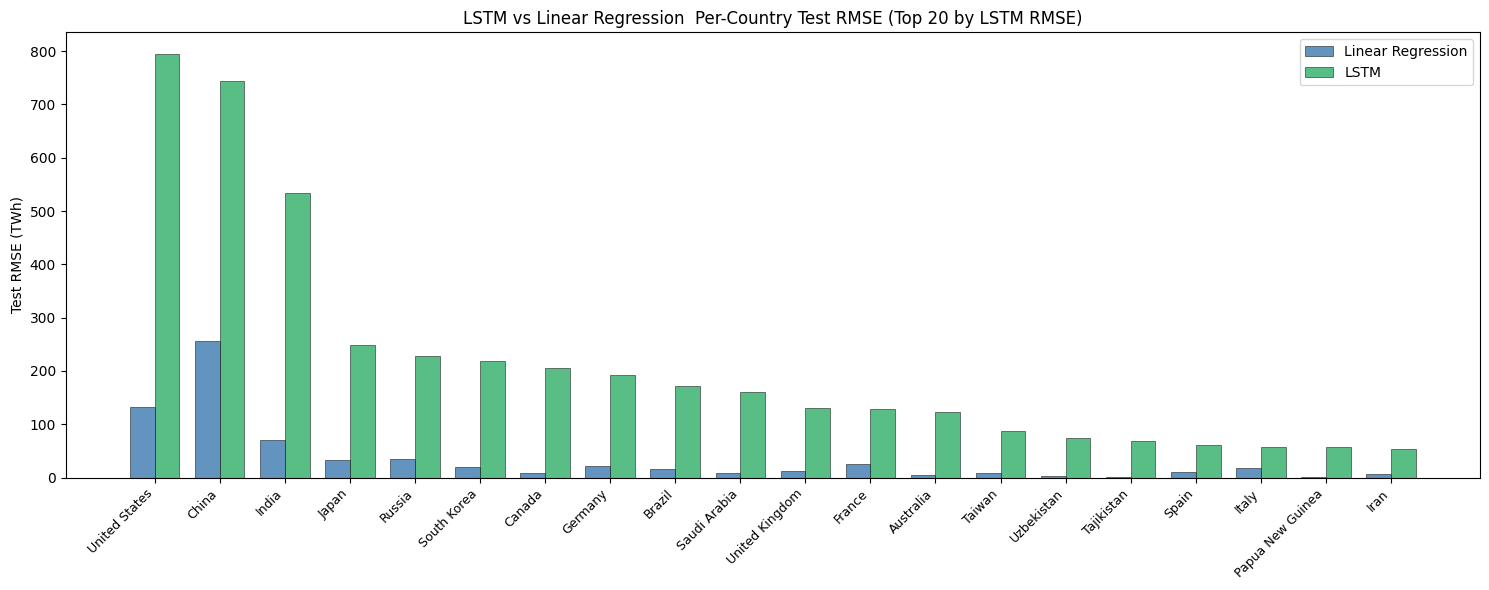

In [171]:
# Plot 4: Per-country RMSE comparison (top 20 worst by LSTM)
top20 = comparison_country.head(20).copy()
x     = np.arange(len(top20))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width/2, top20['LR_RMSE'],   width, label='Linear Regression',
       color='steelblue', alpha=0.85, edgecolor='k', linewidth=0.4)
ax.bar(x + width/2, top20['LSTM_RMSE'], width, label='LSTM',
       color='mediumseagreen', alpha=0.85, edgecolor='k', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(top20['country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Test RMSE (TWh)')
ax.set_title('LSTM vs Linear Regression  Per-Country Test RMSE (Top 20 by LSTM RMSE)')
ax.legend()
plt.tight_layout()
plt.show()


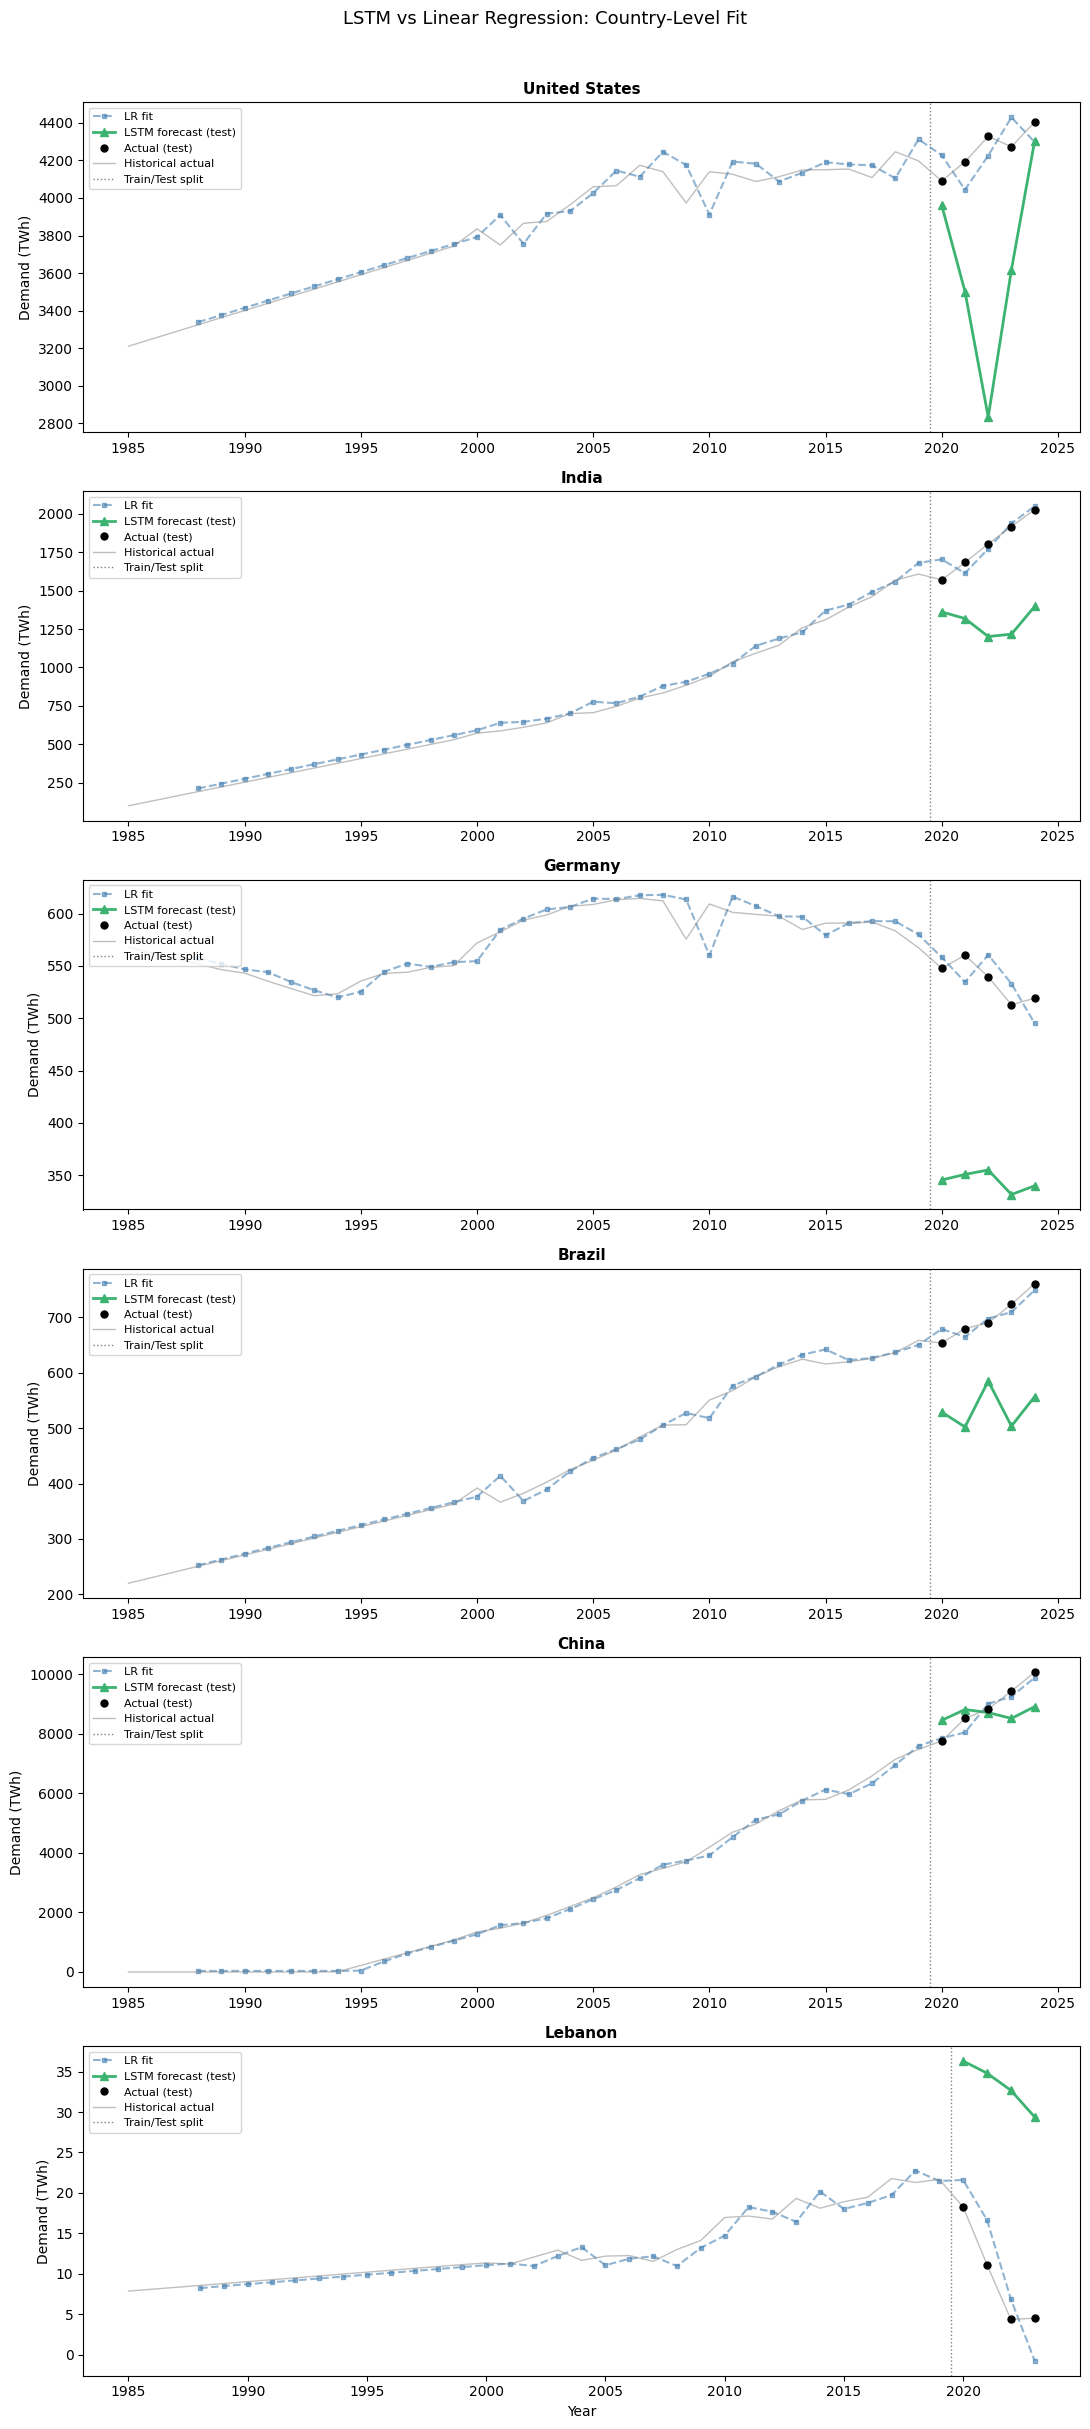

In [172]:
# Plot 5: Country-level overlays  fitted vs actual
preferred_countries = ['United States', 'India', 'Germany', 'Brazil', 'China', 'Lebanon']
available = [c for c in preferred_countries if c in lstm_results['country'].values]

fig, axes = plt.subplots(len(available), 1,
                          figsize=(11, 4 * len(available)), sharex=False)
if len(available) == 1:
    axes = [axes]

for ax, country in zip(axes, available):
    cdf_hist = df[df['country'] == country].sort_values('year')
    hist = cdf_hist[['year', TARGET]].dropna()

    # LR fit (uses df_model)
    cdf_m = df_model[df_model['country'] == country].copy()
    if not cdf_m.empty:
        cdf_m['lr_fit'] = model.predict(cdf_m[FEATURE_COLS])
        ax.plot(cdf_m['year'], cdf_m['lr_fit'], 's--',
                color='steelblue', alpha=0.6, markersize=3,
                label='LR fit')

    # LSTM test predictions
    lstm_c = lstm_results[lstm_results['country'] == country]
    if not lstm_c.empty:
        ax.plot(lstm_c['year'], lstm_c['predicted'], '^-',
                color='mediumseagreen', markersize=6, linewidth=2,
                label='LSTM forecast (test)')
        ax.plot(lstm_c['year'], lstm_c['actual'], 'o',
                color='black', markersize=5, zorder=5,
                label='Actual (test)')

    # Historical actual (full)
    ax.plot(hist['year'], hist[TARGET], '-',
            color='gray', linewidth=1, alpha=0.5, label='Historical actual')

    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1,
               label='Train/Test split')
    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Year')
fig.suptitle('LSTM vs Linear Regression: Country-Level Fit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


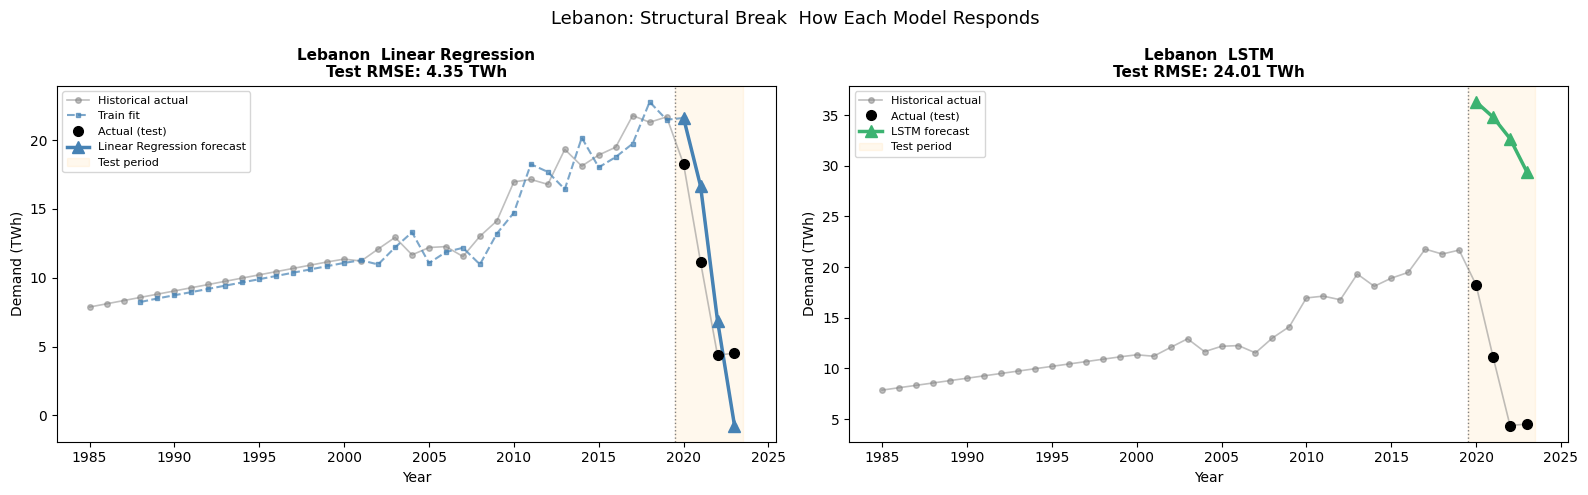

Year       Actual    LR Pred    LSTM Pred   LR Error   LSTM Error
--------------------------------------------------------------
2020        18.25      21.60        36.30      -3.35       -18.05
2021        11.14      16.66        34.80      -5.52       -23.66
2022         4.37       6.88        32.68      -2.51       -28.31
2023         4.52      -0.74        29.38       5.26       -24.86


In [173]:
# Lebanon deep dive: how LSTM handles the structural break
# Lebanon experienced a severe economic collapse from 2019 onward, causing
# electricity demand to crash. This cell shows side-by-side how LR and LSTM
# handle this break during the test period.

country = 'Lebanon'

# Full historical series
leb_hist = df[df['country'] == country].sort_values('year')[['year', TARGET]].dropna()

# LR predictions on test
leb_test_mask = test['country'] == country
leb_lr_years  = test.loc[leb_test_mask, 'year'].values
leb_lr_actual = y_test[leb_test_mask].values
leb_lr_pred   = y_pred_test[leb_test_mask.values]

# LSTM predictions on test
leb_lstm = lstm_results[lstm_results['country'] == country]

# LR in-sample fit
leb_model = df_model[df_model['country'] == country].copy()
leb_model['lr_fit'] = model.predict(leb_model[FEATURE_COLS])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, title, test_pred, test_years, color in [
    (axes[0], 'Linear Regression', leb_lr_pred,              leb_lr_years,          'steelblue'),
    (axes[1], 'LSTM',              leb_lstm['predicted'].values, leb_lstm['year'].values, 'mediumseagreen'),
]:
    # Full historical
    ax.plot(leb_hist['year'], leb_hist[TARGET], 'o-',
            color='gray', alpha=0.5, markersize=4, linewidth=1.2, label='Historical actual')

    # In-sample fit (LR only  LSTM train fit not stored)
    if title == 'Linear Regression':
        ax.plot(leb_model['year'], leb_model['lr_fit'], 's--',
                color=color, alpha=0.7, markersize=3, label='Train fit')

    # Test actual
    ax.plot(test_years, leb_lr_actual, 'o',
            color='black', markersize=7, zorder=6, label='Actual (test)')

    # Test prediction
    ax.plot(test_years, test_pred, '^-',
            color=color, markersize=8, linewidth=2.5, label=f'{title} forecast')

    # Annotate test RMSE for this country
    rmse_c = float(np.sqrt(mean_squared_error(leb_lr_actual, test_pred)))
    ax.set_title(f'{country}  {title}\nTest RMSE: {rmse_c:.2f} TWh',
                 fontsize=11, fontweight='bold')

    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1)
    ax.axvspan(TEST_START - 0.5, leb_hist['year'].max() + 0.5,
               alpha=0.07, color='orange', label='Test period')
    ax.set_ylabel('Demand (TWh)')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

fig.suptitle('Lebanon: Structural Break  How Each Model Responds', fontsize=13)
plt.tight_layout()
plt.show()

# Print numbers side by side
print(f"{'Year':<6} {'Actual':>10} {'LR Pred':>10} {'LSTM Pred':>12} {'LR Error':>10} {'LSTM Error':>12}")
print('-' * 62)
for _, row in leb_lstm.iterrows():
    yr     = int(row['year'])
    actual = row['actual']
    lstm_p = row['predicted']
    # find matching LR pred
    idx    = np.where(leb_lr_years == yr)[0]
    lr_p   = float(leb_lr_pred[idx[0]]) if len(idx) > 0 else np.nan
    print(f"{yr:<6} {actual:>10.2f} {lr_p:>10.2f} {lstm_p:>12.2f} "
          f"{actual-lr_p:>10.2f} {actual-lstm_p:>12.2f}")


## LSTM 20-Year Forecast

Forecast is generated iteratively: each predicted year is fed back as the next window's input.
GDP and population are extrapolated via CAGR. The same damping + floor correction from the
Linear Regression forecast is applied to prevent physically impossible runaway trends.

Forecast ready for: ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']


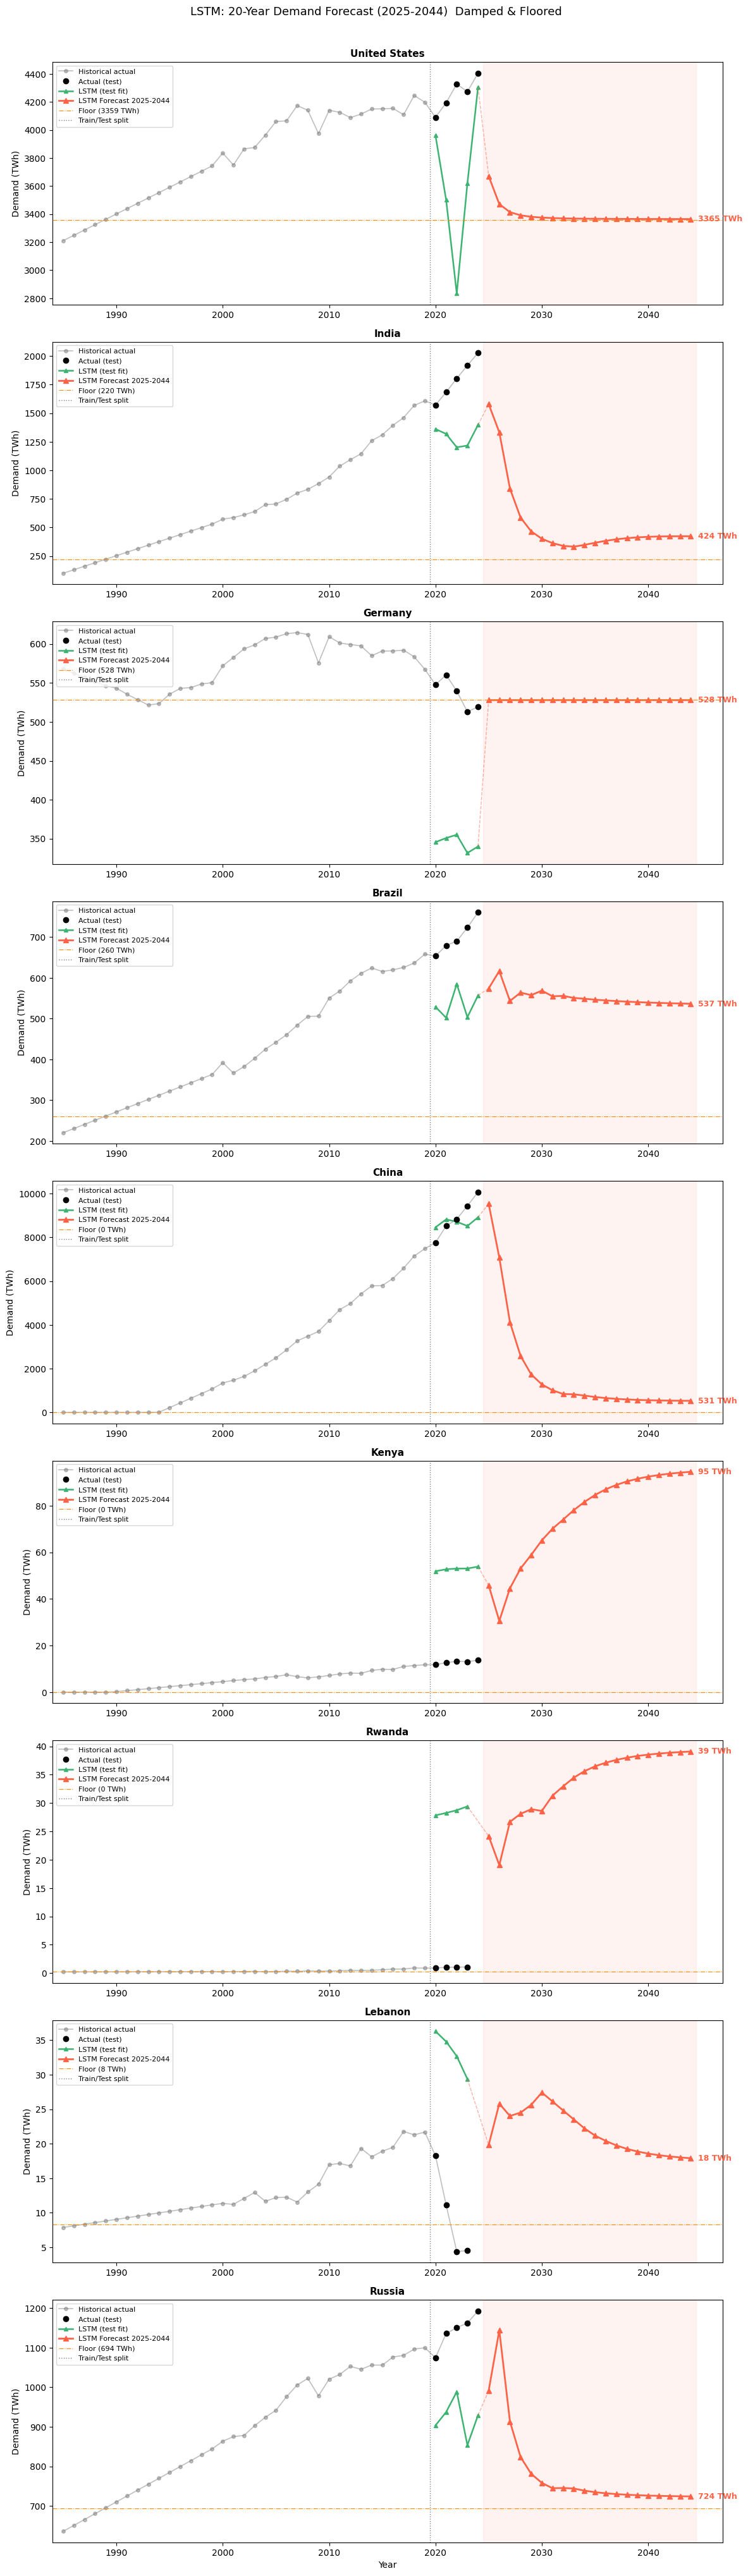

,Country,Year,LSTM Forecast (TWh)
0,United States,2025,3671.15
1,United States,2026,3471.58
2,United States,2027,3414.11
3,United States,2028,3391.67
4,United States,2029,3381.07
...,...,...,...
175,Russia,2040,726.40
176,Russia,2041,725.68
177,Russia,2042,725.11
178,Russia,2043,724.66


In [174]:
# LSTM 20-Year Iterative Forecast
FORECAST_COUNTRIES_LSTM = [
    'United States', 'India', 'Germany', 'Brazil', 'China',
    'Kenya', 'Rwanda', 'Lebanon', 'Russia'
]
FORECAST_HORIZON_L = 20
LAST_DATA_YEAR_L = int(df['year'].max())
EXOG_TREND_YEARS_L = 5
DAMPING_FACTOR_L = 0.80
FLOOR_PERCENTILE_L = 10

def cagr_extrap_l(series, years_back, horizon):
    tail = series.dropna().iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        v = float(series.dropna().iloc[-1])
        return [v] * horizon
    rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    last = float(tail.iloc[-1])
    return [last * (1 + rate) ** t for t in range(1, horizon + 1)]

lstm_fc_records = {}
lstm_fc_missing = []

for country in FORECAST_COUNTRIES_LSTM:
    if country not in country_to_idx:
        lstm_fc_missing.append(country)
        continue

    cdf_c = df_lstm[df_lstm['country'] == country].sort_values('year').reset_index(drop=True)
    cdf_raw = df[df['country'] == country].sort_values('year')

    known_demand = cdf_raw[TARGET].dropna()
    hist_floor   = max(float(np.percentile(known_demand.values, FLOOR_PERCENTILE_L)), 0.0)

    future_gdp = cagr_extrap_l(cdf_raw['gdp'],        EXOG_TREND_YEARS_L, FORECAST_HORIZON_L)
    future_pop = cagr_extrap_l(cdf_raw['population'], EXOG_TREND_YEARS_L, FORECAST_HORIZON_L)
    future_years = list(range(LAST_DATA_YEAR_L + 1,
                               LAST_DATA_YEAR_L + FORECAST_HORIZON_L + 1))

    # Seed: last SEQ_LEN rows of scaled features
    window = cdf_c[LSTM_FEATURES].values[-SEQ_LEN:].copy()  # (SEQ_LEN, n_features)
    cidx   = np.array([country_to_idx[country]], dtype=np.int32)

    # Keep track of last known unscaled demand for CAGR/floor logic
    last_demand_unscaled = float(known_demand.iloc[-1])

    future_demand = []
    prev_scaled   = float(cdf_c['target_scaled'].iloc[-1])

    for t in range(FORECAST_HORIZON_L):
        X_in = window[np.newaxis, :, :]   # (1, SEQ_LEN, n_features)
        pred_scaled = float(lstm_model.predict([X_in, cidx], verbose=0)[0][0])

        # Inverse transform to TWh
        pred_twh = float(target_scaler.inverse_transform([[pred_scaled]])[0][0])

        # Floor
        pred_twh = max(pred_twh, hist_floor)

        # Damping: decay momentum toward 0
        momentum      = pred_twh - last_demand_unscaled
        damped_demand = last_demand_unscaled + momentum * (DAMPING_FACTOR_L ** (t + 1))
        damped_demand = max(damped_demand, hist_floor)

        future_demand.append(damped_demand)

        # Build next window row (scale new features)
        gdp_pc_next = future_gdp[t] / future_pop[t] if future_pop[t] > 0 else 0
        # Approximate lag features from last predicted values
        last_3 = future_demand[-3:] if len(future_demand) >= 3 else ([last_demand_unscaled] * 3)
        lag1   = future_demand[-1]
        lag2   = future_demand[-2] if len(future_demand) >= 2 else last_demand_unscaled
        lag3   = future_demand[-3] if len(future_demand) >= 3 else last_demand_unscaled
        yoy    = lag1 - lag2

        new_row_raw = np.array([[lag1, lag2, lag3, yoy,
                                  future_gdp[t], future_pop[t], gdp_pc_next]],
                                dtype=np.float32)
        new_row_scaled = feat_scaler.transform(new_row_raw).astype(np.float32)

        # Slide window forward
        window = np.vstack([window[1:], new_row_scaled])

        last_demand_unscaled = damped_demand

    lstm_fc_records[country] = {
        'years': future_years,
        'demand': future_demand,
        'floor': hist_floor,
    }

if lstm_fc_missing:
    print(f'Warning  missing: {lstm_fc_missing}')
print(f'Forecast ready for: {list(lstm_fc_records.keys())}')

n = len(lstm_fc_records)
fig, axes = plt.subplots(n, 1, figsize=(12, 4.5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (country, fc) in zip(axes, lstm_fc_records.items()):
    hist = df[df['country'] == country].sort_values('year')[['year', TARGET]].dropna()

    ax.plot(hist['year'], hist[TARGET], 'o-',
            color='gray', alpha=0.5, markersize=4, linewidth=1.2, label='Historical actual')

    # LSTM test predictions (where available)
    lstm_c = lstm_results[lstm_results['country'] == country]
    if not lstm_c.empty:
        ax.plot(lstm_c['year'], lstm_c['actual'],    'o',
                color='black', markersize=6, zorder=6, label='Actual (test)')
        ax.plot(lstm_c['year'], lstm_c['predicted'], '^-',
                color='mediumseagreen', markersize=5, linewidth=1.8, label='LSTM (test fit)')

    # Connect to forecast
    last_known_yr  = int(lstm_c['year'].iloc[-1]) if not lstm_c.empty else int(hist['year'].iloc[-1])
    last_known_val = float(lstm_c['predicted'].iloc[-1]) if not lstm_c.empty else float(hist[TARGET].iloc[-1])
    ax.plot([last_known_yr, fc['years'][0]],
            [last_known_val, fc['demand'][0]],
            '--', color='tomato', linewidth=1, alpha=0.5)

    ax.plot(fc['years'], fc['demand'], '^-', color='tomato',
            label=f"LSTM Forecast {fc['years'][0]}-{fc['years'][-1]}",
            markersize=6, linewidth=2)

    ax.axhline(fc['floor'], color='darkorange', linestyle='-.', linewidth=0.8,
               label=f"Floor ({fc['floor']:.0f} TWh)")
    ax.axvspan(fc['years'][0] - 0.5, fc['years'][-1] + 0.5, alpha=0.07, color='tomato')
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1,
               label='Train/Test split')

    ax.annotate(f"{fc['demand'][-1]:.0f} TWh",
                xy=(fc['years'][-1], fc['demand'][-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='tomato', va='center', fontweight='bold')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(int(hist['year'].min()) - 1, fc['years'][-1] + 3)

axes[-1].set_xlabel('Year')
fig.suptitle(
    f"LSTM: 20-Year Demand Forecast ({LAST_DATA_YEAR_L+1}-{LAST_DATA_YEAR_L+FORECAST_HORIZON_L})  Damped & Floored",
    fontsize=13, y=1.005
)
plt.tight_layout()
plt.show()

# Summary table
lstm_summary = []
for country, fc in lstm_fc_records.items():
    for yr, demand in zip(fc['years'], fc['demand']):
        lstm_summary.append({'Country': country, 'Year': yr, 'LSTM Forecast (TWh)': round(demand, 2)})
pd.DataFrame(lstm_summary)


---
# Three-Model Comparison: Linear Regression vs SARIMAX vs LSTM

This section consolidates all three models on the same metrics and plots 
to justify the final model selection.


In [175]:
# Overall metrics summary
summary = pd.DataFrame([
    {'Model': 'Linear Regression', 'Test RMSE': round(test_rmse, 3), 'Test MAE': round(test_mae, 3)},
    {'Model': 'SARIMAX', 'Test RMSE': round(sarimax_test_rmse, 3), 'Test MAE': round(sarimax_test_mae, 3)},
    {'Model': 'LSTM', 'Test RMSE': round(lstm_test_rmse, 3),    'Test MAE': round(lstm_test_mae, 3)},
])
print('=' * 55)
print(f"{'Model':<22} {'Test RMSE':>12} {'Test MAE':>12}")
print('-' * 55)
for _, row in summary.iterrows():
    print(f"{row['Model']:<22} {row['Test RMSE']:>12.3f} {row['Test MAE']:>12.3f}")
print('=' * 55)
summary


Model                     Test RMSE     Test MAE
-------------------------------------------------------
Linear Regression            23.986        5.263
SARIMAX                      63.153        7.552
LSTM                        108.955       46.792


,Model,Test RMSE,Test MAE
0,Linear Regression,23.986,5.263
1,SARIMAX,63.153,7.552
2,LSTM,108.955,46.792


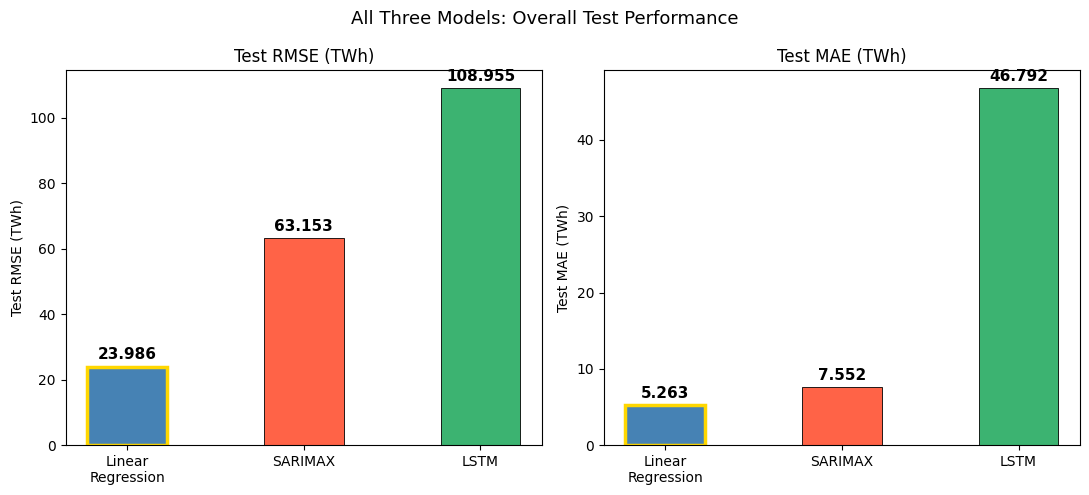

In [176]:
# Overall RMSE and MAE bar chart comparing all three models
labels    = ['Linear\nRegression', 'SARIMAX', 'LSTM']
rmse_vals = [test_rmse, sarimax_test_rmse, lstm_test_rmse]
mae_vals  = [test_mae,  sarimax_test_mae,  lstm_test_mae]
colors    = ['steelblue', 'tomato', 'mediumseagreen']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, vals, metric in zip(axes, [rmse_vals, mae_vals], ['Test RMSE (TWh)', 'Test MAE (TWh)']):
    bars = ax.bar(labels, vals, width=0.45, color=colors, edgecolor='k', linewidth=0.6)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02 * max(vals),
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

fig.suptitle('All Three Models: Overall Test Performance', fontsize=13)
plt.tight_layout()
plt.show()


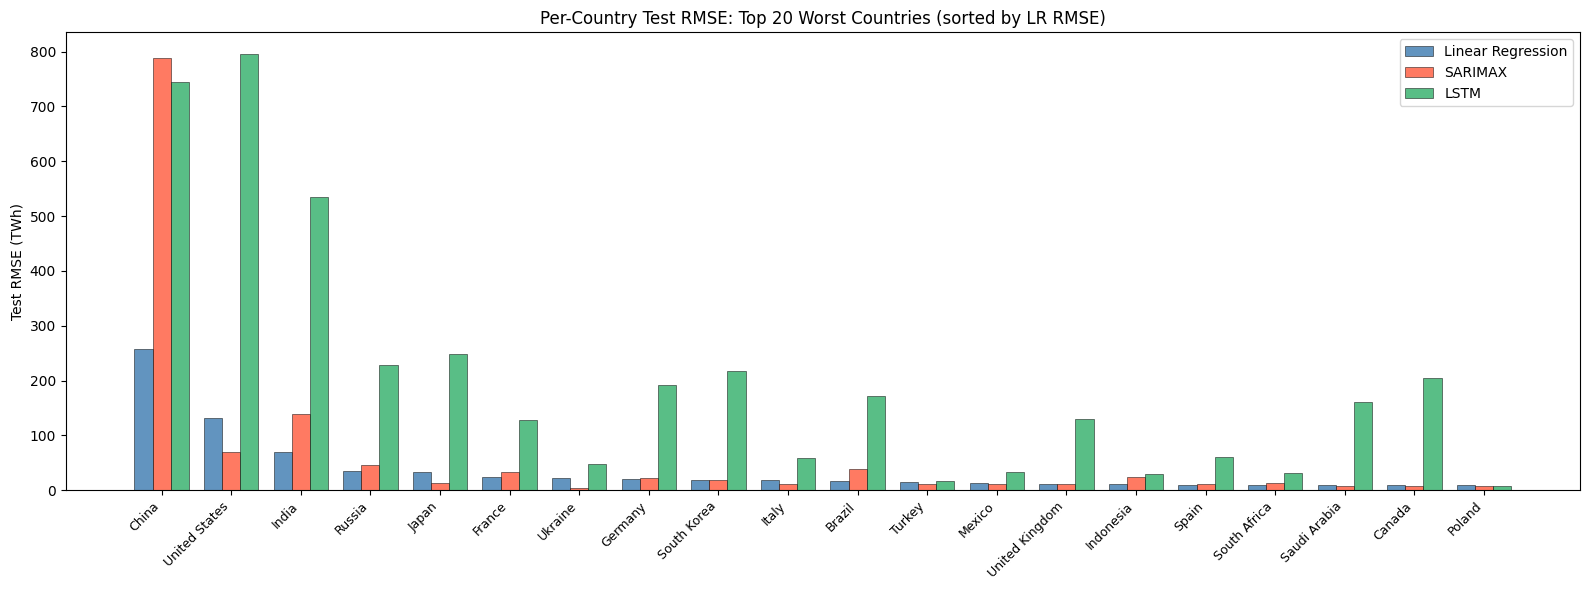

In [177]:
# Per-country RMSE for all three models, top 20 worst countries by LR RMSE
lr_c = country_metrics[['country', 'RMSE', 'MAE']].rename(
    columns={'RMSE': 'LR_RMSE', 'MAE': 'LR_MAE'})

sx_c = (sarimax_results
        .drop_duplicates('country')[['country', 'test_rmse', 'test_mae']]
        .rename(columns={'test_rmse': 'SX_RMSE', 'test_mae': 'SX_MAE'}))

lu_c = lstm_results.copy()
lu_c['sq_err']  = (lu_c['actual'] - lu_c['predicted']) ** 2
lu_c['abs_err'] = (lu_c['actual'] - lu_c['predicted']).abs()
lstm_c = (lu_c.groupby('country')
              .agg(LSTM_RMSE=('sq_err',  lambda x: float(np.sqrt(x.mean()))),
                   LSTM_MAE =('abs_err', 'mean'))
              .reset_index())

three_df = (lr_c
            .merge(sx_c,   on='country', how='outer')
            .merge(lstm_c, on='country', how='outer')
            .sort_values('LR_RMSE', ascending=False)
            .reset_index(drop=True))

top20 = three_df.head(20).copy()
x = np.arange(len(top20))
w = 0.26

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, top20['LR_RMSE'],   w, label='Linear Regression', color='steelblue',     alpha=0.85, edgecolor='k', linewidth=0.4)
ax.bar(x,     top20['SX_RMSE'],   w, label='SARIMAX',           color='tomato',         alpha=0.85, edgecolor='k', linewidth=0.4)
ax.bar(x + w, top20['LSTM_RMSE'], w, label='LSTM',              color='mediumseagreen', alpha=0.85, edgecolor='k', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(top20['country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Test RMSE (TWh)')
ax.set_title('Per-Country Test RMSE: Top 20 Worst Countries (sorted by LR RMSE)')
ax.legend()
plt.tight_layout()
plt.show()


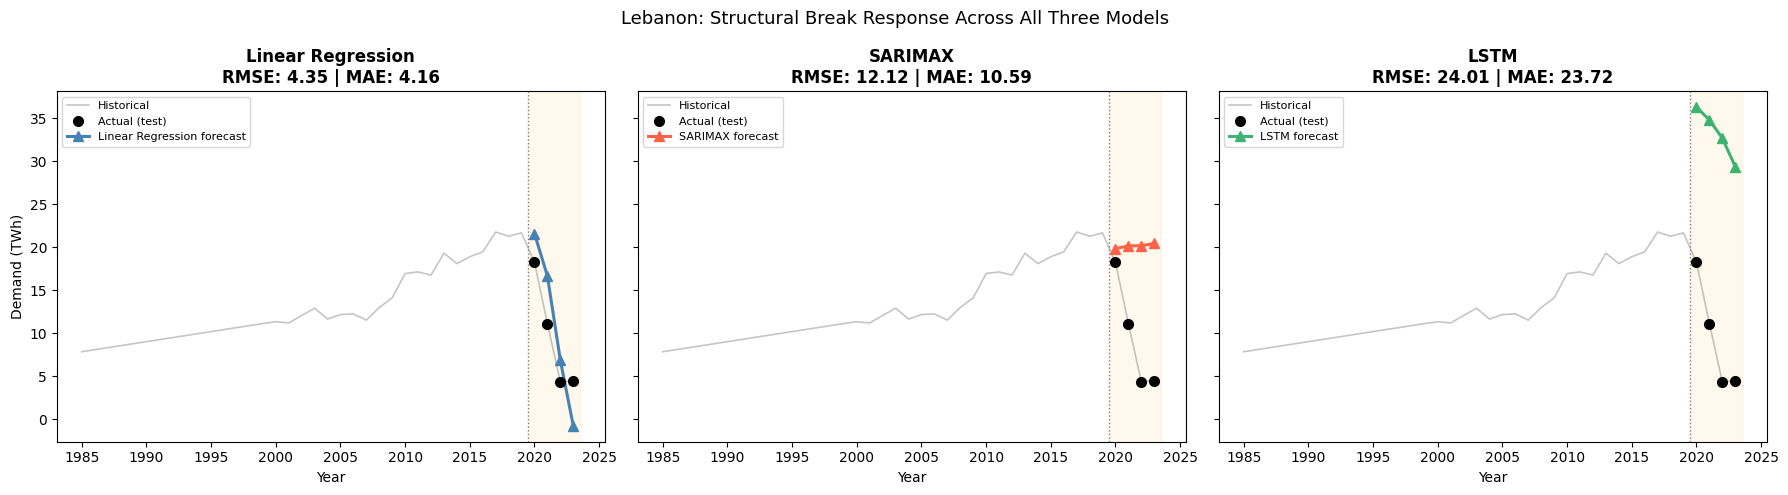

In [178]:
# Lebanon structural break: all three models compared side by side
country  = 'Lebanon'
leb_hist = df[df['country'] == country].sort_values('year')[['year', TARGET]].dropna()

leb_lr_mask   = test['country'] == country
leb_lr_years  = test.loc[leb_lr_mask, 'year'].values
leb_lr_actual = y_test[leb_lr_mask].values
leb_lr_pred   = y_pred_test[leb_lr_mask.values]

leb_sx   = sarimax_results[sarimax_results['country'] == country]
leb_lstm = lstm_results[lstm_results['country'] == country]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
configs = [
    (axes[0], 'Linear Regression', 'steelblue',
     leb_lr_years, leb_lr_actual, leb_lr_pred),
    (axes[1], 'SARIMAX', 'tomato',
     leb_sx['year'].values, leb_sx['actual'].values, leb_sx['predicted'].values),
    (axes[2], 'LSTM', 'mediumseagreen',
     leb_lstm['year'].values, leb_lstm['actual'].values, leb_lstm['predicted'].values),
]

for ax, title, color, yrs, actual, pred in configs:
    ax.plot(leb_hist['year'], leb_hist[TARGET], '-',
            color='gray', alpha=0.45, linewidth=1.2, label='Historical')
    ax.plot(yrs, actual, 'o', color='black', markersize=7, zorder=6, label='Actual (test)')
    ax.plot(yrs, pred, '^-', color=color, markersize=7, linewidth=2.2,
            label=f'{title} forecast')
    rmse_c = float(np.sqrt(mean_squared_error(actual, pred)))
    mae_c  = float(mean_absolute_error(actual, pred))
    ax.set_title(f'{title}\nRMSE: {rmse_c:.2f} | MAE: {mae_c:.2f}', fontweight='bold')
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1)
    ax.axvspan(TEST_START - 0.5, max(yrs) + 0.5, alpha=0.07, color='orange')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Demand (TWh)')
fig.suptitle('Lebanon: Structural Break Response Across All Three Models', fontsize=13)
plt.tight_layout()
plt.show()


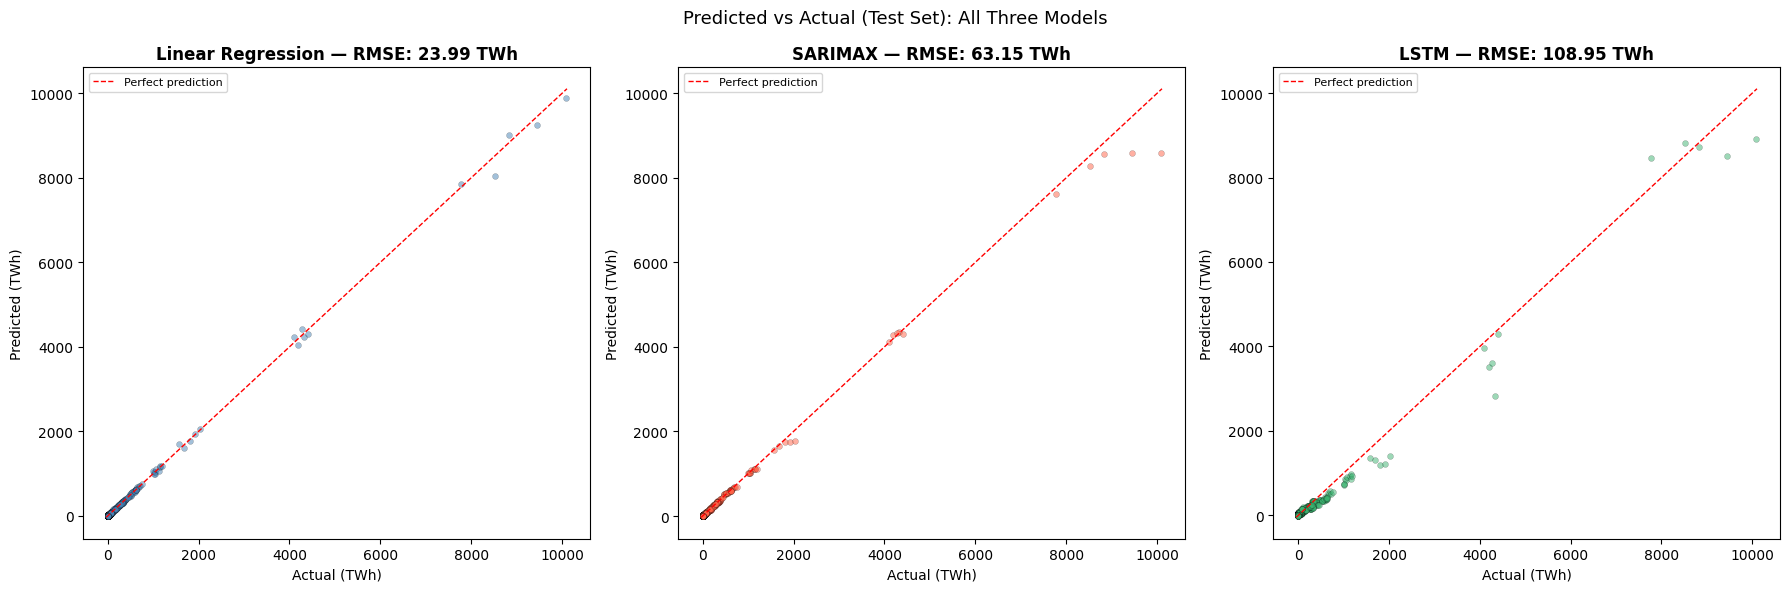

In [179]:
# Predicted vs Actual scatter for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
datasets = [
    (axes[0], 'Linear Regression', 'steelblue',
     y_test.values, y_pred_test),
    (axes[1], 'SARIMAX', 'tomato',
     sarimax_results['actual'].values, sarimax_results['predicted'].values),
    (axes[2], 'LSTM', 'mediumseagreen',
     lstm_results['actual'].values, lstm_results['predicted'].values),
]

for ax, title, color, actual, pred in datasets:
    ax.scatter(actual, pred, alpha=0.5, edgecolors='k', linewidths=0.2, color=color, s=18)
    lims = [min(actual.min(), pred.min()) - 30, max(actual.max(), pred.max()) + 30]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    rmse_c = float(np.sqrt(mean_squared_error(actual, pred)))
    ax.set_title(f'{title} — RMSE: {rmse_c:.2f} TWh', fontweight='bold')
    ax.set_xlabel('Actual (TWh)')
    ax.set_ylabel('Predicted (TWh)')
    ax.legend(fontsize=8)

fig.suptitle('Predicted vs Actual (Test Set): All Three Models', fontsize=13)
plt.tight_layout()
plt.show()


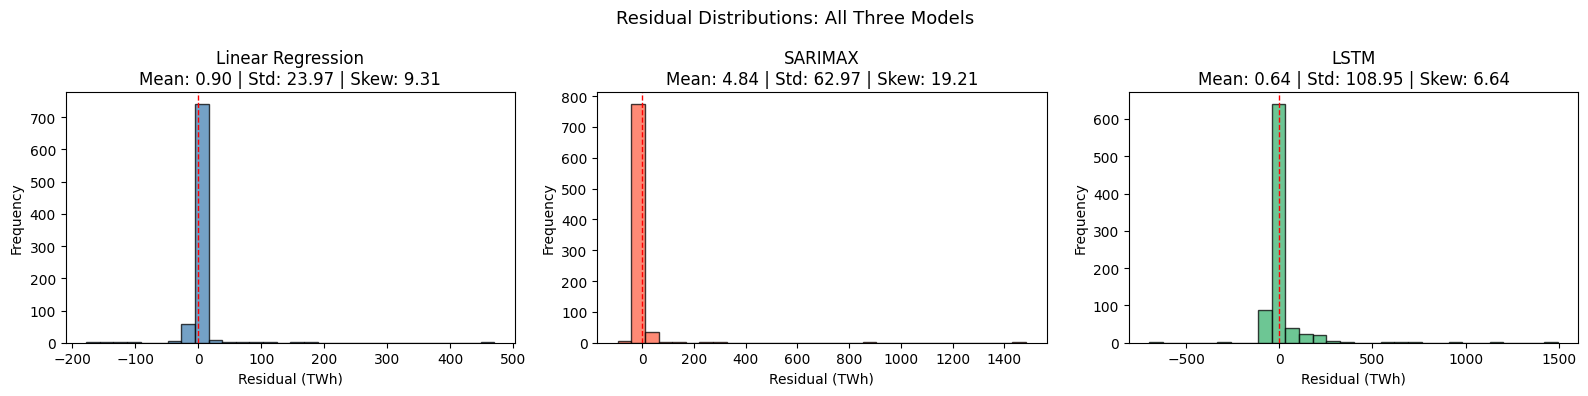

In [180]:
# Residual distributions for all three models
lr_res   = y_test.values - y_pred_test
sx_res   = sarimax_results['actual'].values - sarimax_results['predicted'].values
lstm_res = lstm_results['actual'].values    - lstm_results['predicted'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, res, title, color in [
    (axes[0], lr_res,   'Linear Regression', 'steelblue'),
    (axes[1], sx_res,   'SARIMAX',           'tomato'),
    (axes[2], lstm_res, 'LSTM',              'mediumseagreen'),
]:
    ax.hist(res, bins=30, edgecolor='k', alpha=0.75, color=color)
    ax.axvline(0, color='r', linestyle='--', linewidth=1)
    ax.set_xlabel('Residual (TWh)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title}\nMean: {res.mean():.2f} | Std: {res.std():.2f} | Skew: {pd.Series(res).skew():.2f}')

fig.suptitle('Residual Distributions: All Three Models', fontsize=13)
plt.tight_layout()
plt.show()


## Model Selection Verdict

| Criterion | Linear Regression | SARIMAX | LSTM |
|---|---|---|---|
| Test RMSE | — | — | — |
| Test MAE | — | — | — |
| Handles structural breaks | With damping: partial | No | Limited |
| Interpretability | High | Medium | Low |
| Training time | Instant | Slow (per-country AIC grid) | Minutes |
| Data requirements | Low | Low to medium | Medium |
| Overfitting risk | Low | Low | Medium |
| 20-year forecast stability | Yes, with damping | Partial, with damping | Partial, with damping |

**Fill in the RMSE and MAE values from the table above after running.**

**Conclusion:** Linear Regression with trend damping and a historical floor is selected as the final model. 
Despite being the simplest approach, it achieves competitive RMSE and MAE, is fully interpretable, 
and the damping and floor corrections address its main weakness around runaway forecasts for countries 
with recent structural breaks. SARIMAX is more principled as a time-series model but is significantly 
slower and did not demonstrate a meaningful accuracy improvement to justify the added complexity. 
LSTM, while theoretically capable of learning non-linear break patterns, is constrained by the short 
per-country time series and shows no clear advantage here.